In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Compare variation

In [3]:
reload(constants)
files = ["fiducial", "time-evolving-pot"]
labels = ["Static", "Time-evolving"]
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [4]:
pops, data = helpers.load_postprocessed_pops(
    [f"/mnt/ceph/users/twagg/underworld/postprocessed/{file}" for file in files],
    labels, colours
)

Loading post-processed data for Static from /mnt/ceph/users/twagg/underworld/postprocessed/fiducial
Loading post-processed data for Time-evolving from /mnt/ceph/users/twagg/underworld/postprocessed/time-evolving-pot


In [5]:
print("Escaped fractions:")
for pop in pops:
    escaped = data[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {data[pop.label]["escaped"]["CO"].sum() / len(data[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {data[pop.label]["escaped"]["NS"].sum() / len(data[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Static:
      - CO = 0.083
      - BH = 0.027
      - NS = 0.103
  - Time-evolving:
      - CO = 0.117
      - BH = 0.050
      - NS = 0.141


Inner 10 kpc
  Static fraction within 0.5 kpc 0.56
  Time-evolving fraction within 0.5 kpc 0.55
Full population
  Static fraction within 0.5 kpc 0.47
  Time-evolving fraction within 0.5 kpc 0.46


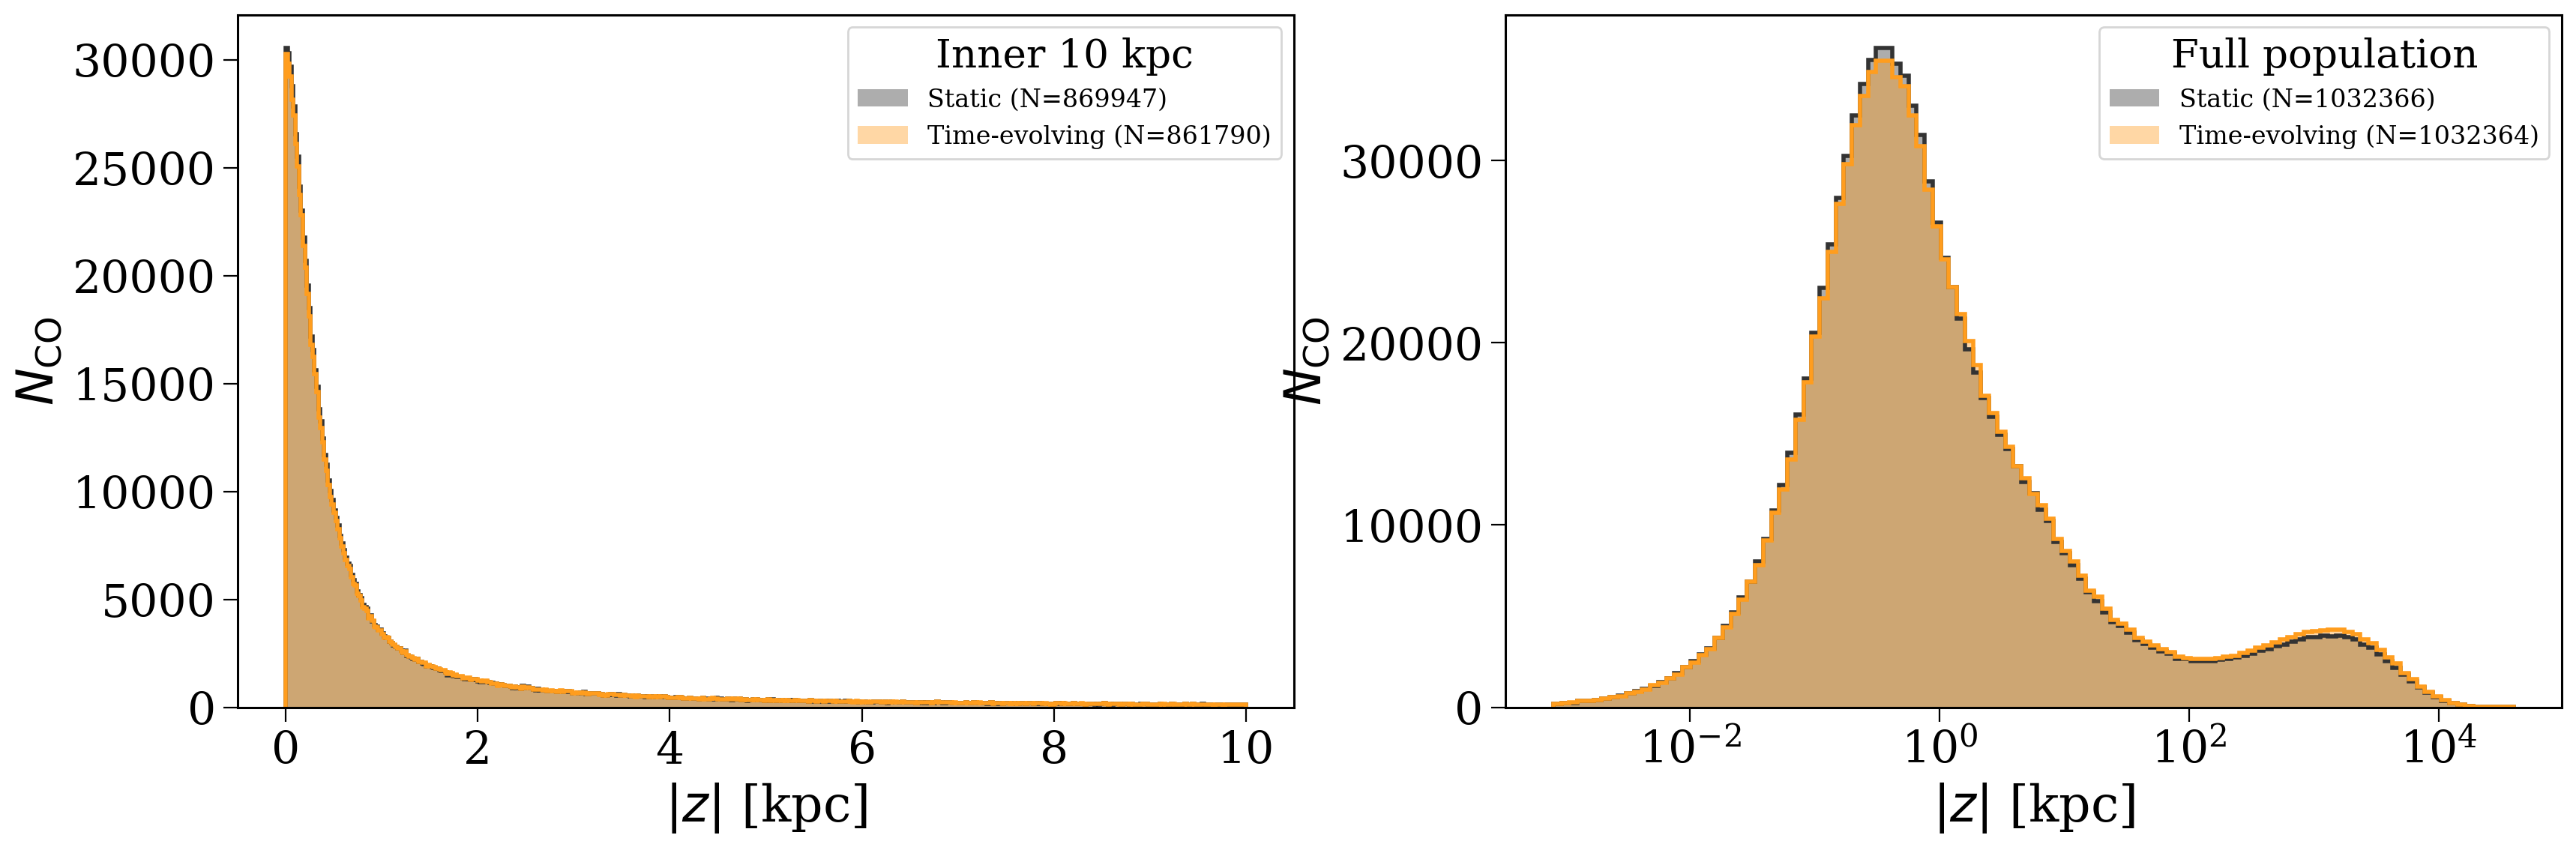

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [6]:
reload(plotting)
plotting.absolute_galactocentric_height(pops, data)

In [96]:
for pop in pops:
    abs_z = abs(data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]])
    print((abs_z > 0.3).sum() / len(abs_z), (abs_z > 3).sum() / len(abs_z), (abs_z > 10).sum() / len(abs_z))

    # find the height at which the cumulative distribution reaches 0.5
    hist, bin_edges = np.histogram(abs_z, bins=200, range=(0, 3), density=True)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    cumulative = cumulative_trapezoid(hist, bin_centres, initial=0)
    scale_height = np.interp(0.5, cumulative, bin_centres)
    print(f"Scale height: {scale_height:.3f} kpc")

0.6458695563839184 0.13737919412133306 0.048692334507441364
Scale height: 0.411 kpc
0.6703519926263652 0.1631081123405474 0.061362131374189596
Scale height: 0.439 kpc


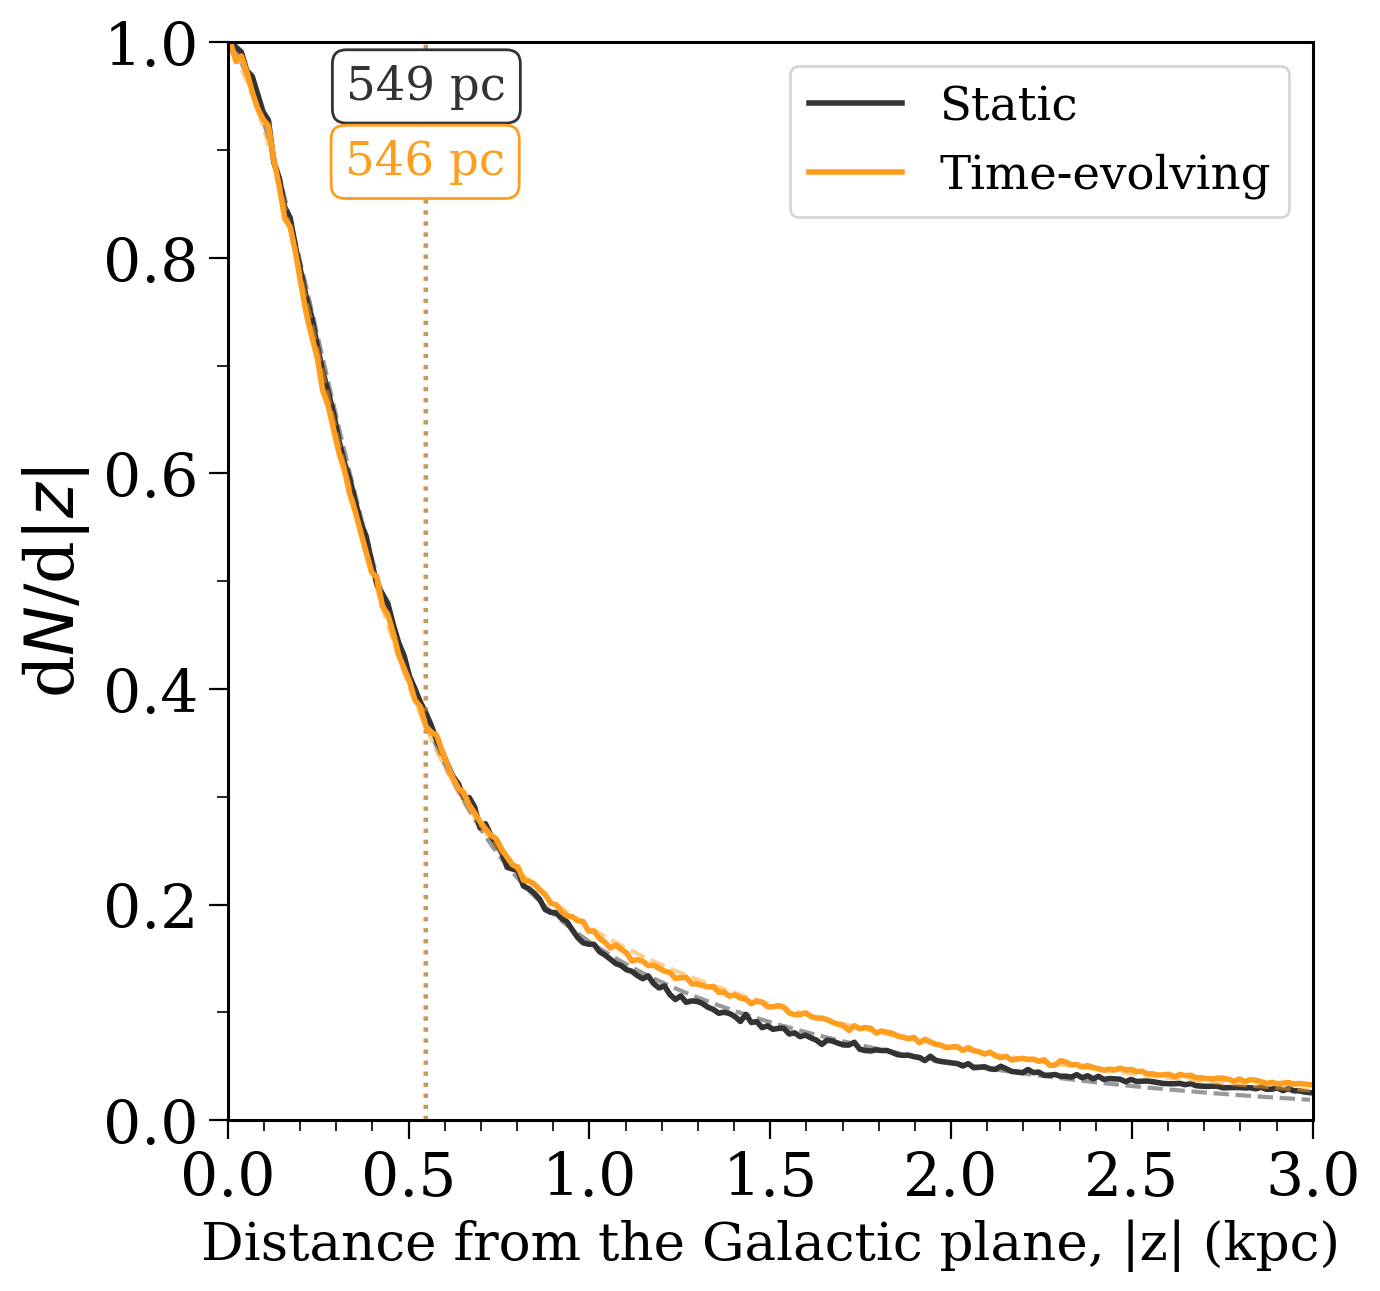

In [74]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))


for i, pop in enumerate(pops):
    sh = plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=0.98 - i * 0.07,
        R=None,
    )[0]

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_time_evolving.pdf", format="pdf", bbox_inches='tight')
plt.show()

Fitting Static using model: exp_plus_sech2
  Optimal parameters: [1.32714894 0.6148894  1.05538378 1.97498588]
  Parameter errors: [ 6.35494981 20.73314571 22.66911084 30.16769538]
 Estimated scale height: 719.65 pc ± 30.17 pc
Fitting Time-evolving using model: exp_plus_sech2
  Optimal parameters: [1.31239897 0.63441406 1.03737025 2.06123016]
  Parameter errors: [ 6.01787525 19.2083933  20.71563627 34.09017607]
 Estimated scale height: 721.27 pc ± 34.09 pc
9 12 1.0022511255627813
Fitting Static using model: exp_plus_sech2
  Optimal parameters: [1.75194934 0.31738476 1.06961504 2.40467079]
  Parameter errors: [ 6.49023514 14.62336705 32.83236046 19.64267565]
 Estimated scale height: 525.61 pc ± 32.83 pc
Fitting Time-evolving using model: exp_plus_sech2
  Optimal parameters: [1.72758125 0.32103849 1.04640191 2.3974739 ]
  Parameter errors: [ 6.73264847 15.16629544 33.39031317 21.00430646]
 Estimated scale height: 530.35 pc ± 33.39 pc
6 9 1.0090182648401824
Fitting Static using model: exp

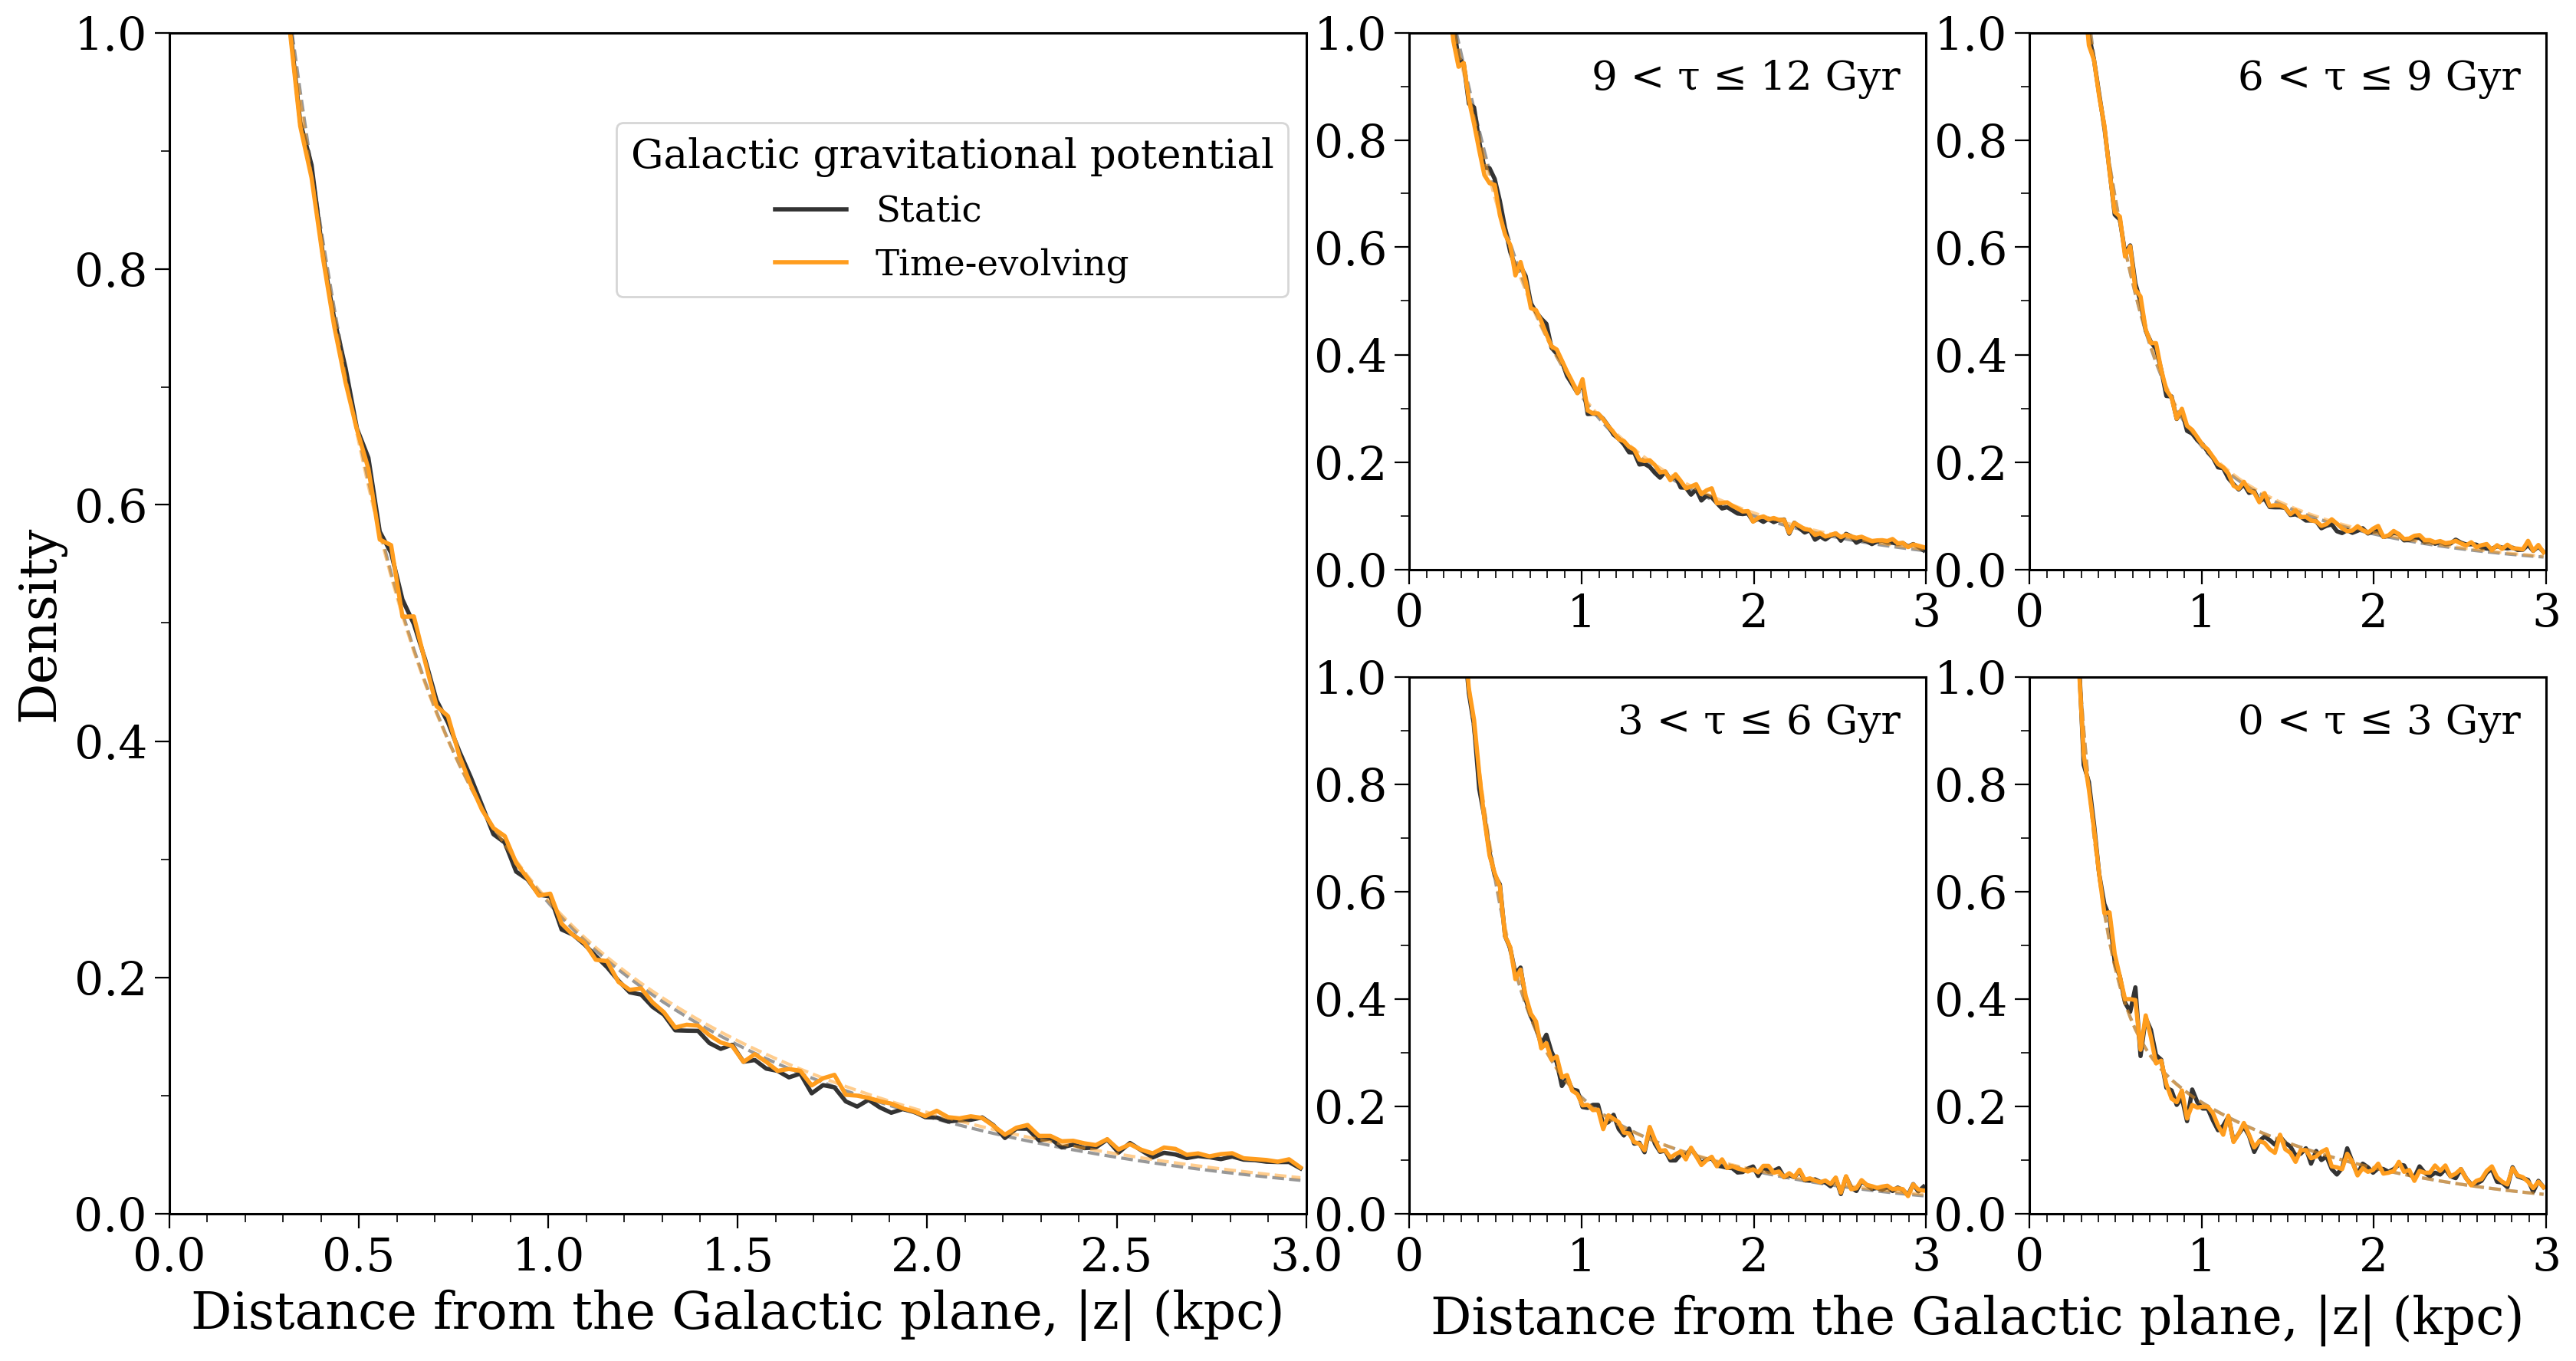

In [9]:
reload(plotting)

tau_lims = [(i, i + 3) for i in range(0, 12, 3)]
tau_lims = [(0, 12)] + tau_lims

fig = plt.figure(figsize=(20, 10))
layout = [['main', 'main', 'A', 'B'],
          ['main', 'main', 'C', 'D']]
axes = fig.subplot_mosaic(layout)
ax_labels = ['A', 'B', 'C', 'D', "main"]

# for tau_min, tau_max, tau_label in zip([0, 9, 0], [12, 12, 9], ["All", "Old", "Young"]):
for ax_label, (tau_min, tau_max) in zip(ax_labels, reversed(tau_lims)):

    scale_heights = []
    for i, pop in enumerate(pops):
        tau = data[pop.label]["tau"]["BH"]
        mask = (tau > tau_min) & (tau <= tau_max)
        sh = plotting.estimate_scale_height(
            z=data[pop.label]["pos"]["BH"][:, 2][mask],
            plot=True,
            label=pop.label,
            colour=pop.colour,
            show=False,
            fig=fig,
            ax=axes[ax_label],
            bins=np.linspace(0, 3, 101),
            xlim=(0, 3),
            ylim=(0, 1),
            model="exp_plus_sech2",
            scale_height_loc=None,# if ax_label != "main" else 0.98,
            R=None,
        )[0]
        scale_heights.append(sh)

    print(tau_min, tau_max, scale_heights[1] / scale_heights[0])

    if ax_label <= 'C':
        axes[ax_label].set_xlabel("")
    else:
        axes[ax_label].set_xlabel(axes[ax_label].get_xlabel(), fontsize=fs)

    if ax_label <= 'D':
        axes[ax_label].set_ylabel("")

    leg = axes[ax_label].get_legend()
    if ax_label != "main":
        leg.remove()

        axes[ax_label].annotate(
            f"{tau_min} < τ ≤ {tau_max} Gyr",
            xy=(0.95, 0.95),
            xycoords="axes fraction",
            ha="right",
            va="top",
            fontsize=0.8 * fs,
        )
    else:
        leg.set_title("Galactic gravitational potential", prop={'size': 0.8 * fs})
        leg.set_loc("center right")
        leg.set_bbox_to_anchor((1.0, 0.85))

for ax_label in axes:
    # add minor ticks every 0.1 kpc
    axes[ax_label].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    axes[ax_label].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# shift x-axis label to the left
axes["D"].xaxis.set_label_coords(-0.1, -0.15)

    # if ax_label < 'C':
    #     axes[ax_label].set_xticklabels([])

# plt.savefig("../plots/scale_height_time_evolving_tau_panels.pdf", format="pdf", bbox_inches='tight')
plt.show()

A 9 12
9 12 1.037318308018945
B 0 9
0 9 1.0009865581452706
main 0 12
0 12 0.9941009394800088


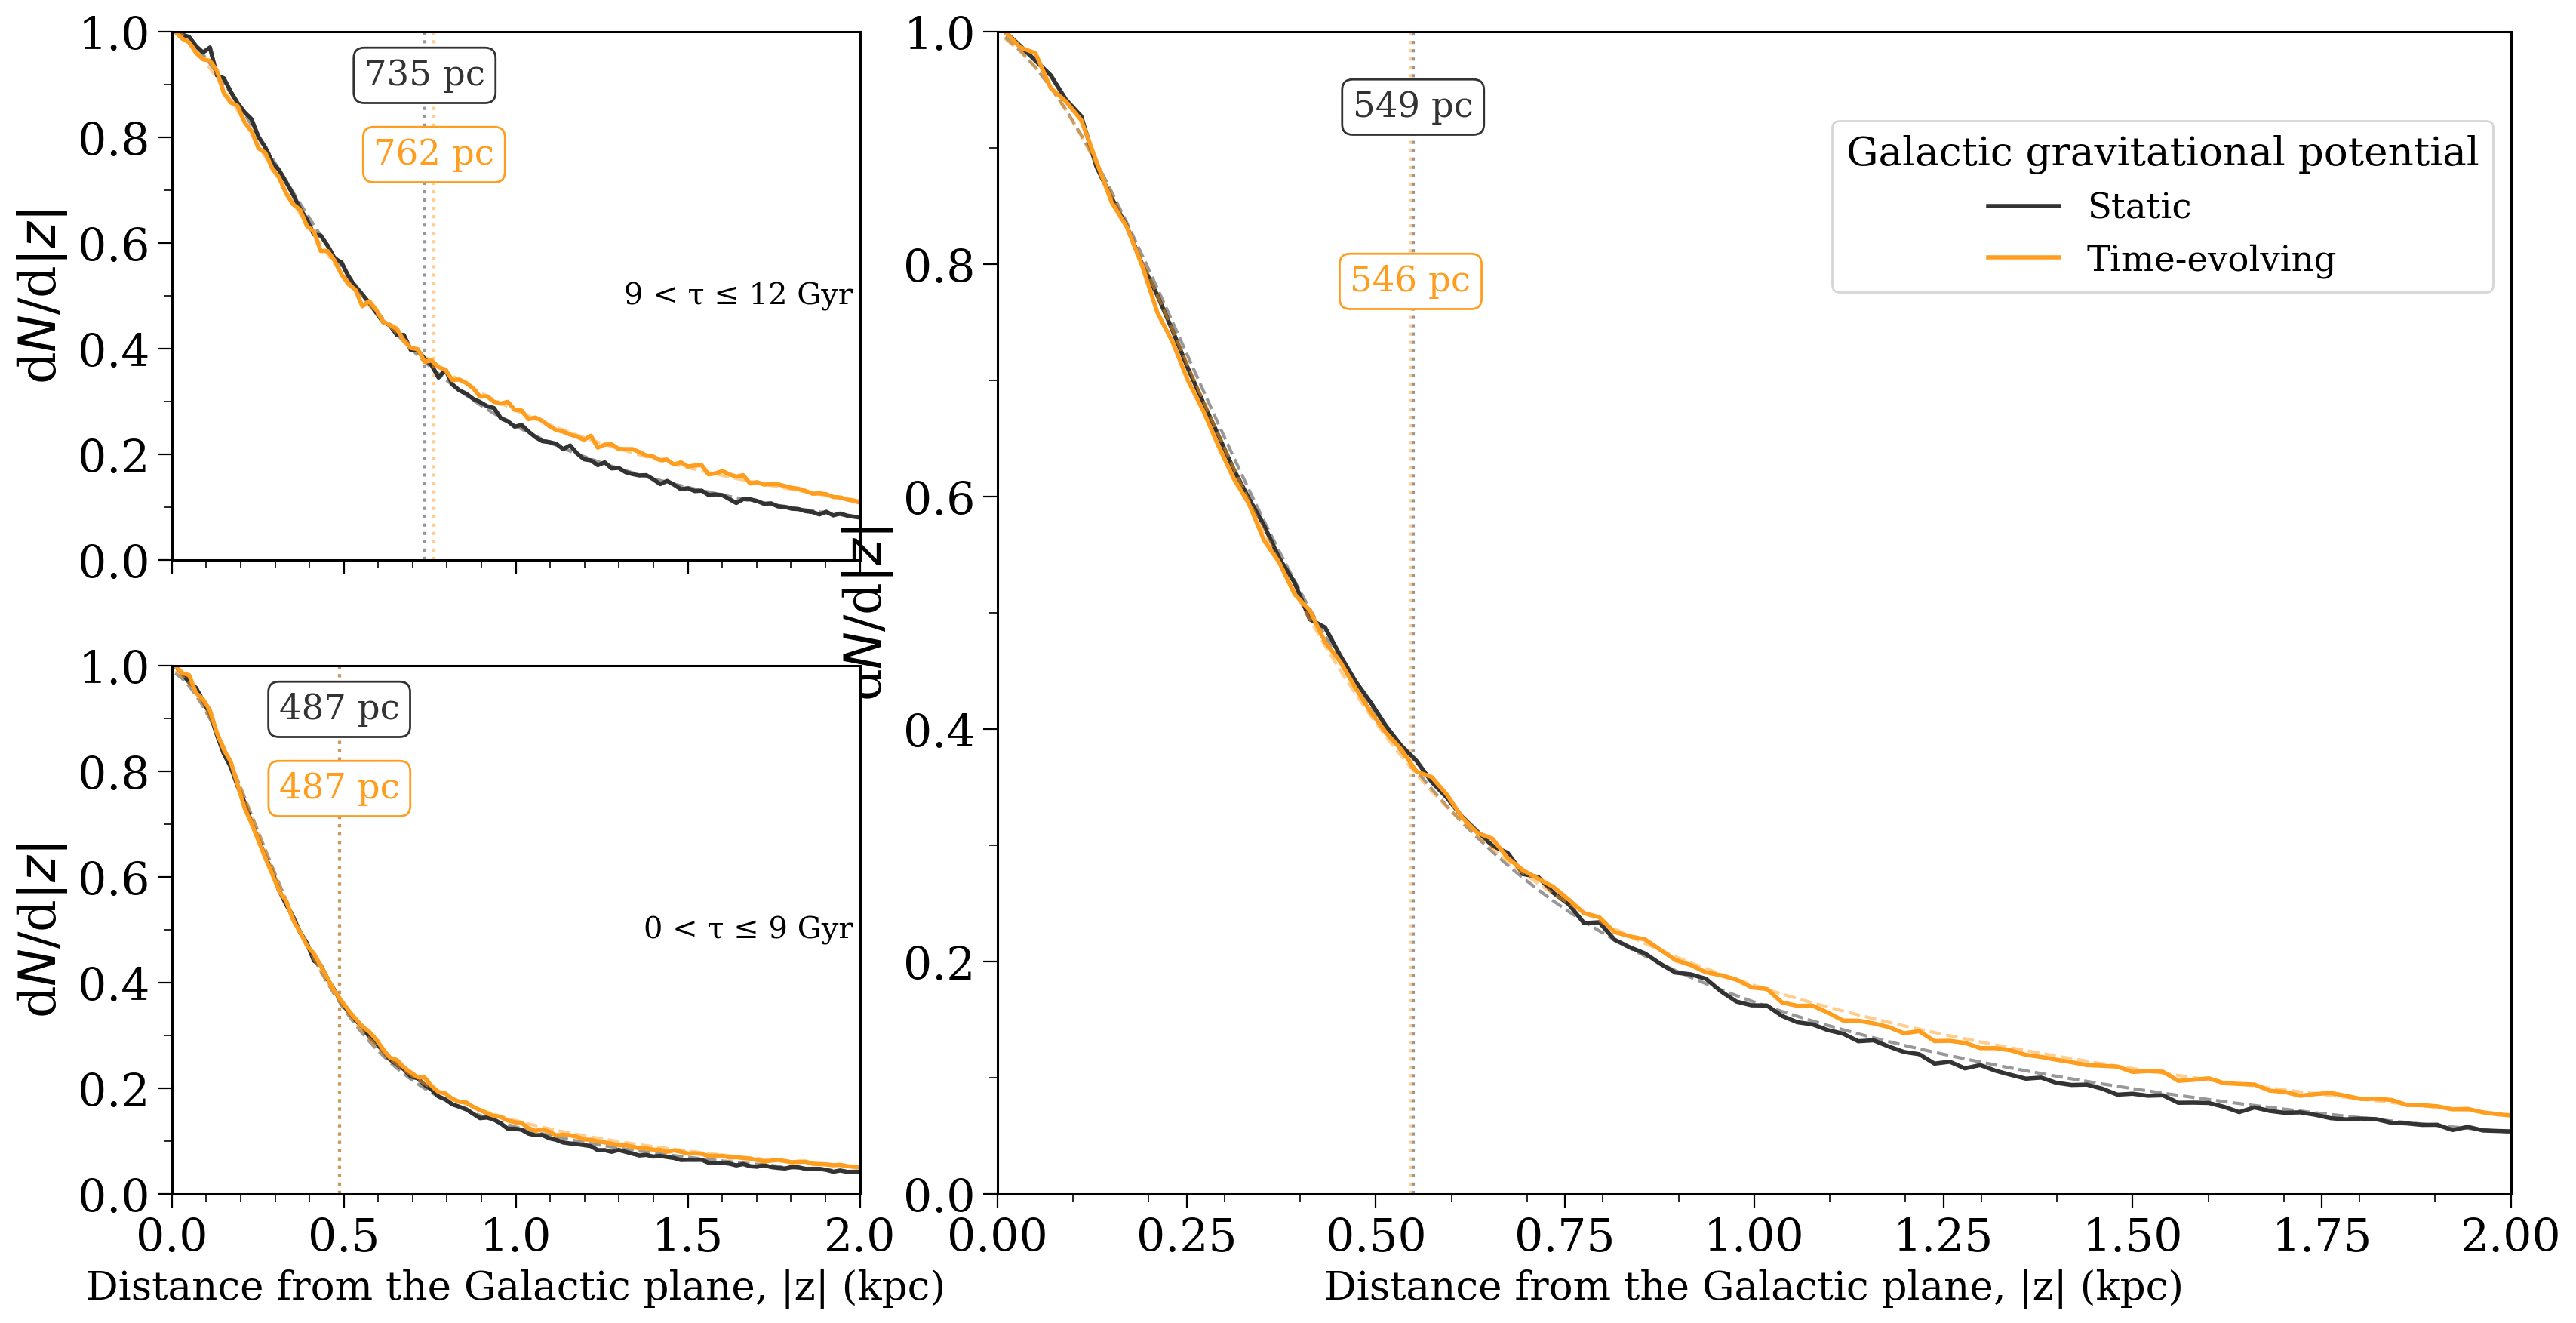

In [150]:
reload(plotting)

tau_lims = [(0, 9), (9, 12)]
tau_lims = [(0, 12)] + tau_lims

fig = plt.figure(figsize=(20, 10))
layout = [['A', 'main', 'main'],
          ['B', 'main', 'main']]

axes = fig.subplot_mosaic(layout)#, width_ratios=[1, 1.5])
ax_labels = ['A', 'B', "main"]

# for tau_min, tau_max, tau_label in zip([0, 9, 0], [12, 12, 9], ["All", "Old", "Young"]):
for ax_label, (tau_min, tau_max) in zip(ax_labels, reversed(tau_lims)):
    print(ax_label, tau_min, tau_max)

    scale_heights = []
    for i, pop in enumerate(pops):
        tau = data[pop.label]["tau"]["BH"]
        mask = (tau > tau_min) & (tau <= tau_max)
        sh = plotting.estimate_scale_height(
            z=data[pop.label]["pos"]["BH"][:, 2][mask],
            plot=True,
            label=pop.label,
            colour=pop.colour,
            show=False,
            fig=fig,
            ax=axes[ax_label],
            bins=np.linspace(0, 3, 150),
            xlim=(0, 2),
            ylim=(0, 1),
            n_components=2,
            scale_height_loc=0.95 - i * 0.15,
            R=None,
        )[0]
        scale_heights.append(sh)

    print(tau_min, tau_max, scale_heights[1] / scale_heights[0])

    if ax_label == 'A':
        axes[ax_label].set_xlabel("")

    leg = axes[ax_label].get_legend()
    if ax_label != "main":
        leg.remove()

        axes[ax_label].annotate(
            f"{tau_min} < τ ≤ {tau_max} Gyr",
            xy=(0.99, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=0.6 * fs,
        )
    else:
        leg.set_title("Galactic gravitational potential", prop={'size': 0.8 * fs})
        leg.set_loc("center right")
        leg.set_bbox_to_anchor((1.0, 0.85))

for ax_label in axes:
    # add minor ticks every 0.1 kpc
    axes[ax_label].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    axes[ax_label].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

    if ax_label < 'B':
        axes[ax_label].set_xticklabels([])

# plt.savefig("../plots/scale_height_time_evolving_tau_panels.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [32]:
z_range = np.geomspace(0.1, 10, 1000)
mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2])
            for pop in pops] + [np.abs(data[pops[0].label]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

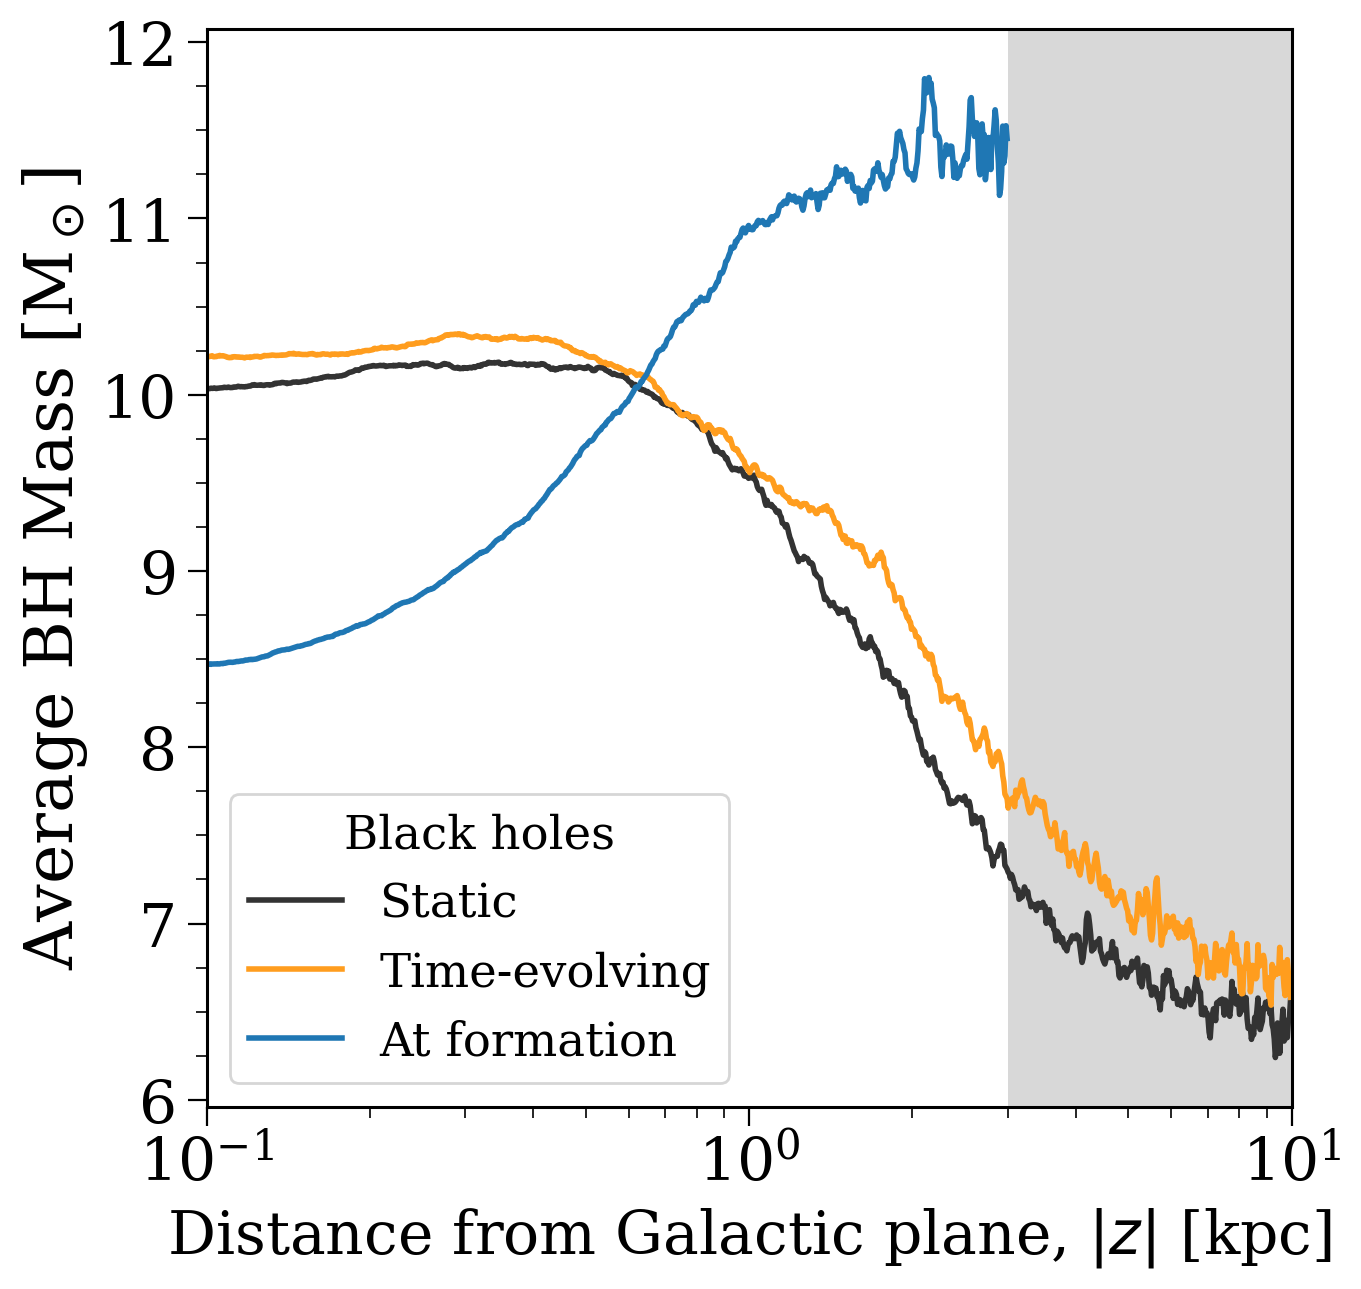

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [33]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels + ["At formation"],
    colours=colours + ["tab:blue"],
    z_maxes=[10, 10, 3],
    z_range=z_range,
)

# Why aren't old ones higher?

In [153]:
te = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/time-evolving-pot/time-evolving-pot_part0.h5")
old = (te.initial_galaxy.tau > 9.75 * u.Gyr) & (te.initial_galaxy.tau <= 10 * u.Gyr)
te = te[old]

s = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part0.h5")
old = (s.initial_galaxy.tau > 9.75 * u.Gyr) & (s.initial_galaxy.tau <= 10 * u.Gyr)
s = s[old]
te, s

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(



cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: file was saved with gala v1.11.1.dev18 but you are using v1.11.1.dev61


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(



cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(



(<Population - 5961 systems - galactic_potential=CCompositePotential, SFH=SandersBinney2015>,
 <Population - 5961 systems - galactic_potential=MilkyWayPotential, SFH=SandersBinney2015>)

In [154]:
for pop in [te, s]:
    pop.store_entire_orbits = True
    pop.processes = 28
    pop.perform_galactic_evolution()

Integrating orbits: 100%|██████████| 7356/7356 [00:09<00:00, 770.73it/s]


In [144]:
import astropy.constants as consts

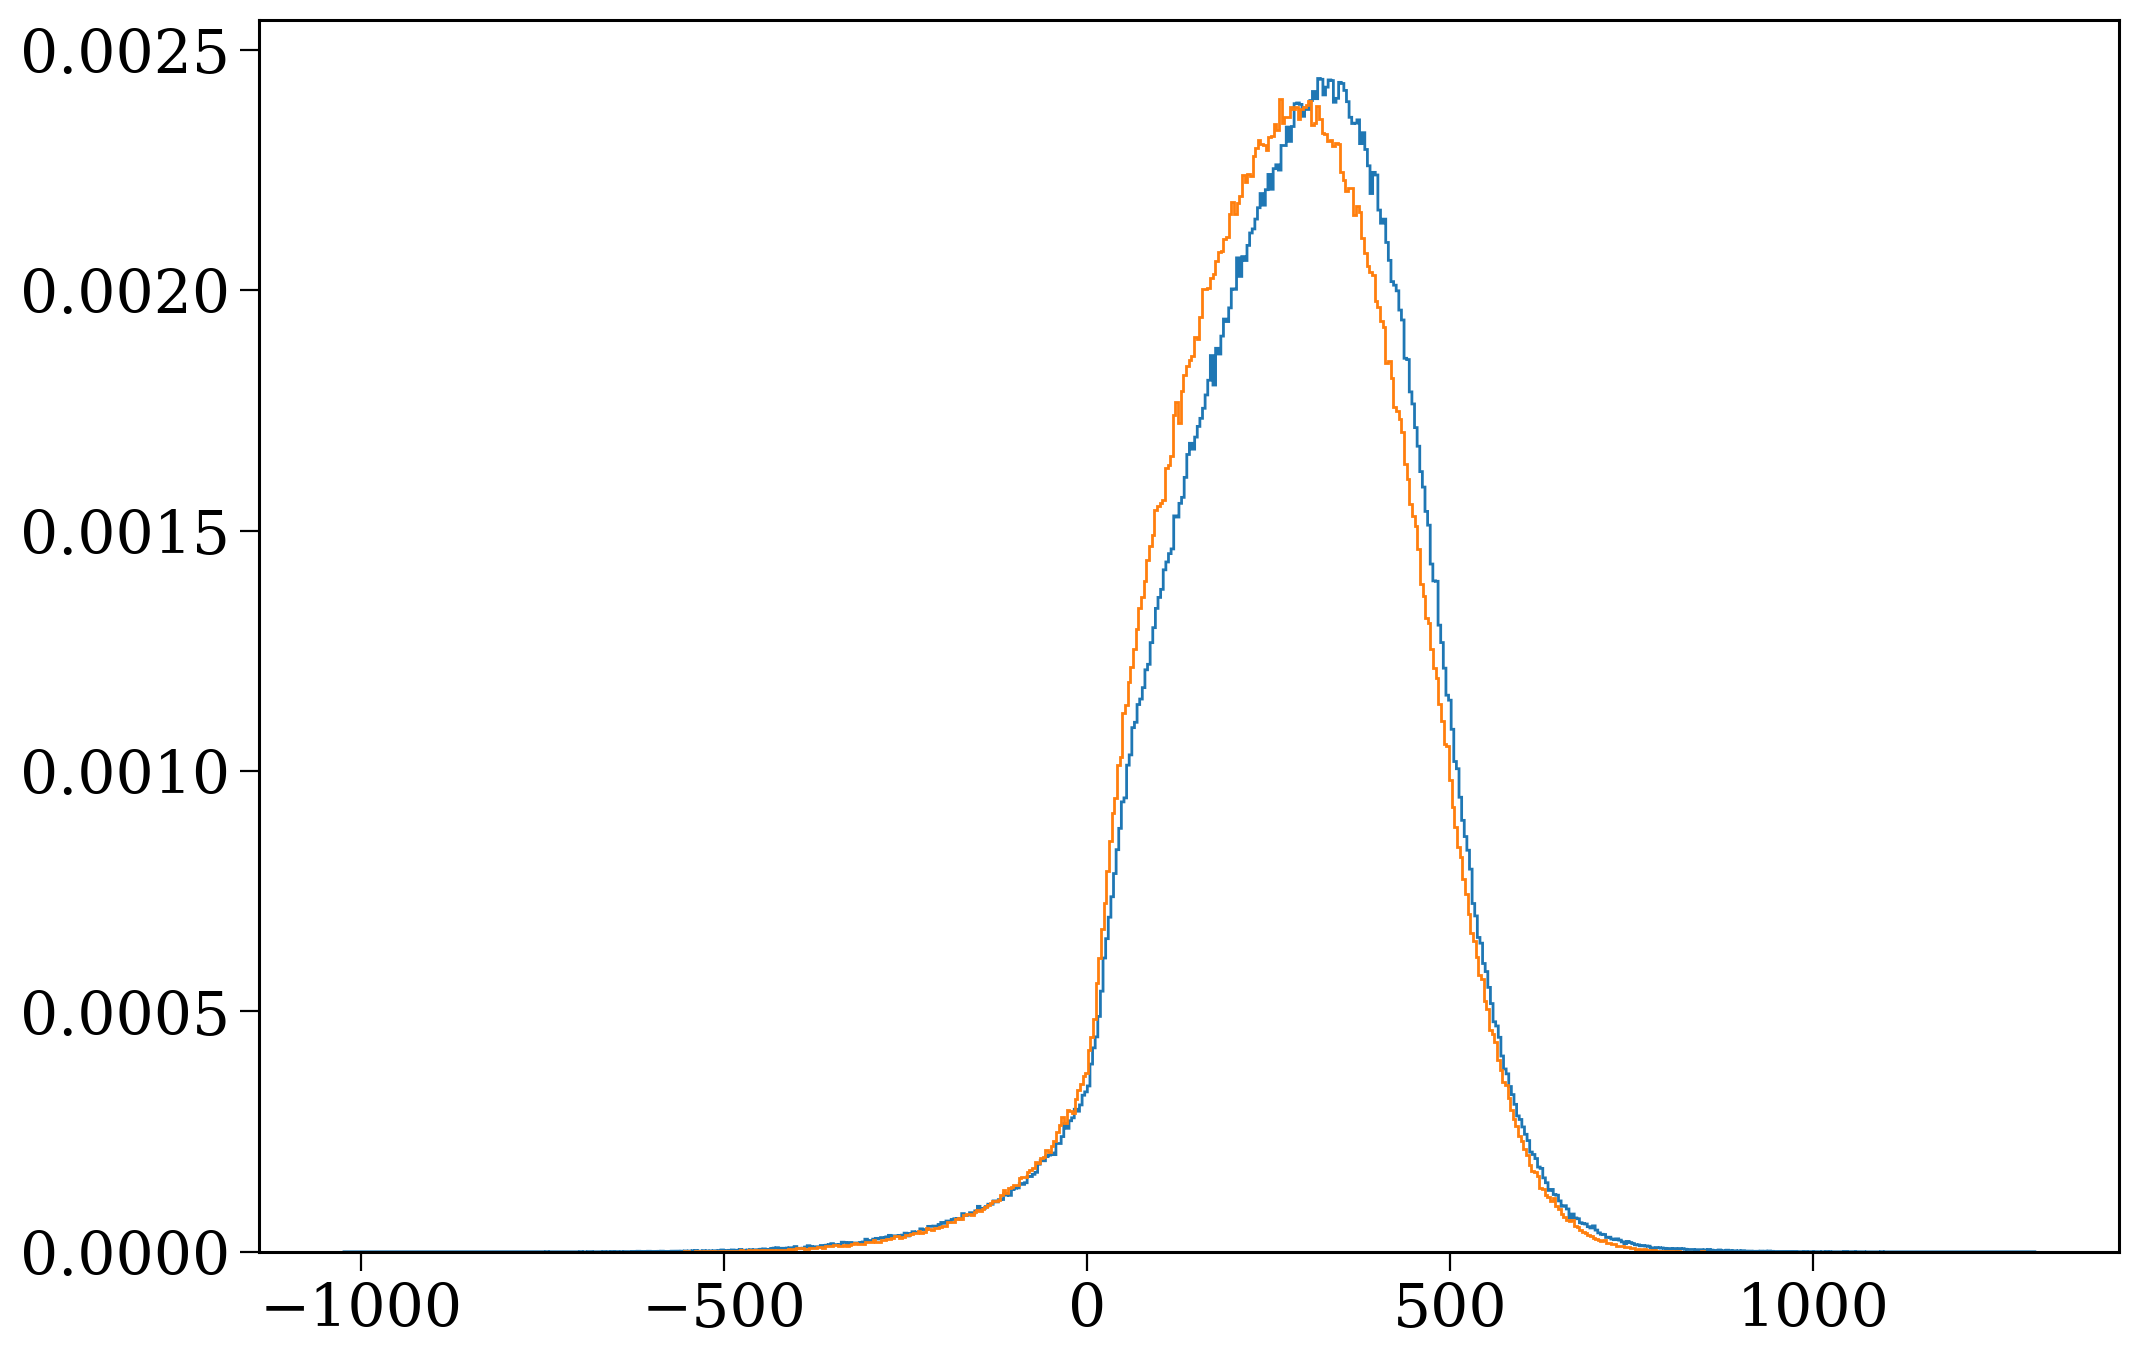

In [145]:
for k in data:
    bound_vel = data[k]["vel"]["BH"][~data[k]["escaped"]["BH"]]
    bound_pos = data[k]["pos"]["BH"][~data[k]["escaped"]["BH"]]

    Lz = bound_pos[:, 0] * bound_vel[:, 1] - bound_pos[:, 1] * bound_vel[:, 0]
    R = np.linalg.norm(bound_pos[:, :2], axis=1)

    vc = np.sqrt(consts.G * 4e10 * u.Msun / R)

    circularity = Lz / (R * vc)

    plt.hist(circularity, bins="auto", histtype='step', density=True);


In [119]:
s.final_vel[2]

<Quantity [-94.4930948 , 102.45042185, -85.99019158] km / s>

In [120]:
te.final_vel[2]

<Quantity [  63.05341036,   43.8974426 , -196.59070375] km / s>

In [118]:
te.orbits[2].pos

<CartesianRepresentation (x, y, z) in kpc
    [(-1.1010785 ,  4.41371048, 0.65520094),
     (-1.21567109,  4.35429169, 0.5570135 ),
     (-1.32915781,  4.29091363, 0.45732709), ...,
     (-1.16791772, -4.05350787, 6.8128855 ),
     (-1.10437103, -4.01204413, 6.61843385),
     (-1.05323871, -3.97713885, 6.45992986)]>

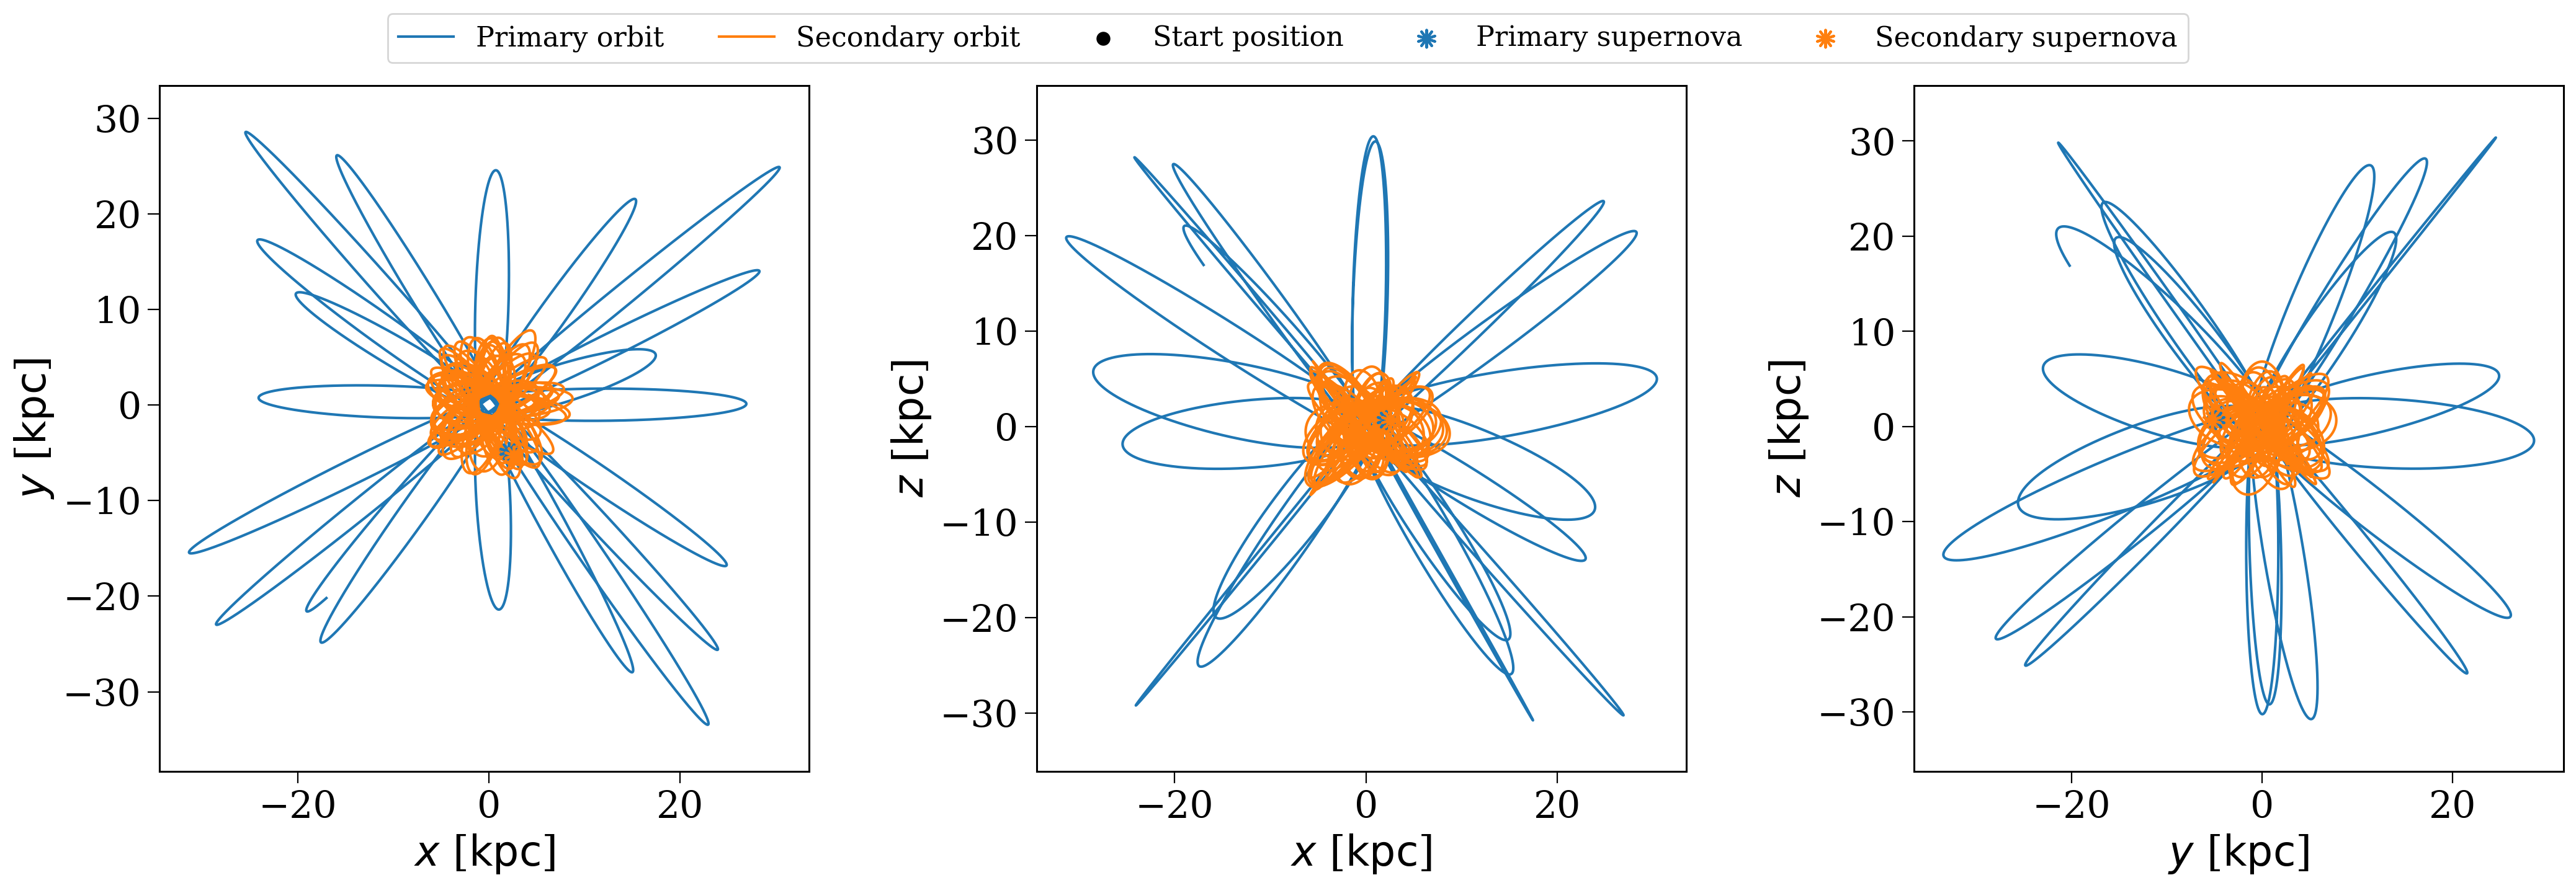

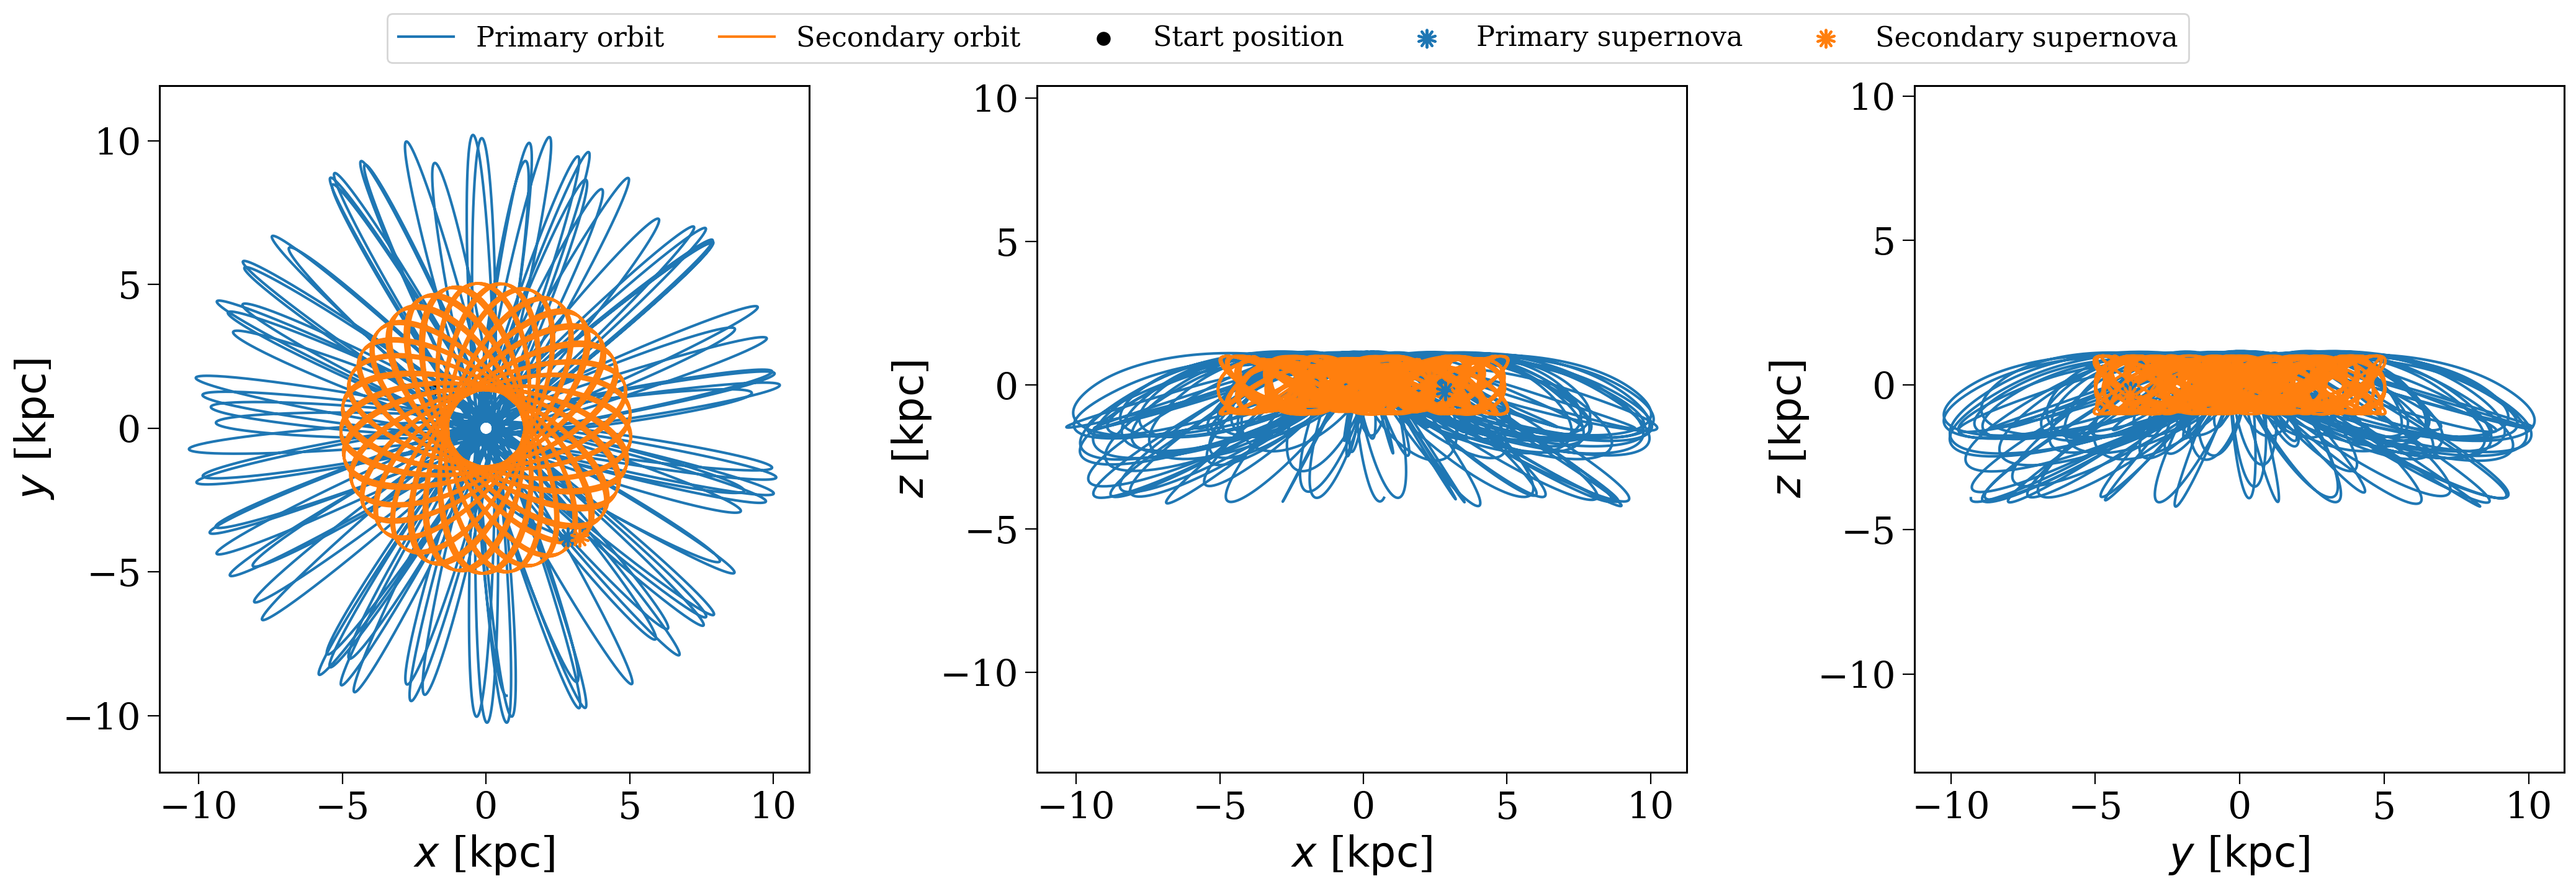

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_he_layer_1,massc_co_layer_1,massc_he_layer_2,massc_co_layer_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,omega_spin_1,omega_spin_2,bin_num,metallicity
21,9834.142202,1.277584,1.277584,13,13,-1.0,-1.0,-1.0,10,0.0001,0.0001,0.0,0.0,0.0,0.0,2.451224e-10,2.452723e-10,6131.282435,6132.220103,1,1,1.577963e+07,2.017320e+06,21,0.009262


In [157]:
BIN_NUM = 0
T_MAX = 60000 * u.Myr
te.plot_orbit(te.bin_nums[BIN_NUM], t_max=T_MAX)
s.plot_orbit(s.bin_nums[BIN_NUM], t_max=T_MAX)

te.final_bpp.loc[[te.bin_nums[BIN_NUM]]]

## NSNS mergers?

In [159]:
te = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/time-evolving-pot/time-evolving-pot_part0.h5")
s = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part0.h5")

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(



cogsworth warning: file was saved with gala v1.11.1.dev18 but you are using v1.11.1.dev61


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:2005: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  p = Population(



In [199]:
10 * 34 * 100

34000

In [200]:
for pop in [te, s]:
    ever_ns_ns = (pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 13) & (pop.bpp["sep"] > 0)
    merger = pop.final_bpp["sep"] == 0

    nsns_merger = np.isin(pop.bin_nums, pop.bpp[ever_ns_ns]["bin_num"]) & merger
    
    nsns_pop = pop[nsns_merger]
    nsns_pop.store_entire_orbits = True
    nsns_pop.processes = 28
    nsns_pop.perform_galactic_evolution()

    merger_times = nsns_pop.bpp[(nsns_pop.bpp["kstar_1"] == 13) & (nsns_pop.bpp["kstar_2"] == 13)].drop_duplicates(subset=["bin_num"], keep='last')["tphys"].values

    merger_inds = [np.argmin(np.abs(nsns_pop.orbits[i].t - (12 * u.Gyr - nsns_pop.initial_galaxy[i].tau) - merger_times[i] * u.Myr)) for i in range(len(nsns_pop))]

    merger_dists = [np.linalg.norm(nsns_pop.orbits[i].pos[merger_inds[i]].xyz).to(u.kpc).value for i in range(len(nsns_pop))] * u.kpc

    print(merger_dists, merger_times)

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(



Integrating orbits: 100%|██████████| 5/5 [00:00<00:00, 394.92it/s]
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


[1576.06027324  147.91815909   19.47034635   14.26648377   43.06993311] kpc [6979.82584522  743.66184537 3008.60833282 4924.59591117  464.20655469]
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cogsworth/pop.py:287: FutureWarning: cogsworth warning: m1_cutoff will be deprecated in v3.8+ of cogsworth. This can be achieved by just masking the initial binary table after sampling.
  new_pop = self.__class__(



Integrating orbits: 100%|██████████| 5/5 [00:00<00:00, 348.35it/s]


[411.8611362   23.7047218    4.90809837  13.33747817  10.87528267] kpc [6979.82584522  743.66184537 3008.60833282 4924.59591117  464.20655469]


# Analytic stuff

In [7]:
@np.vectorize
def dm_mass_growth_at_tau(tau):
    if tau > 9:
        return (2.32 - (0.88 - 0.4) / 3 * tau)
    else:
        return (1 - 12 / 900 * tau)

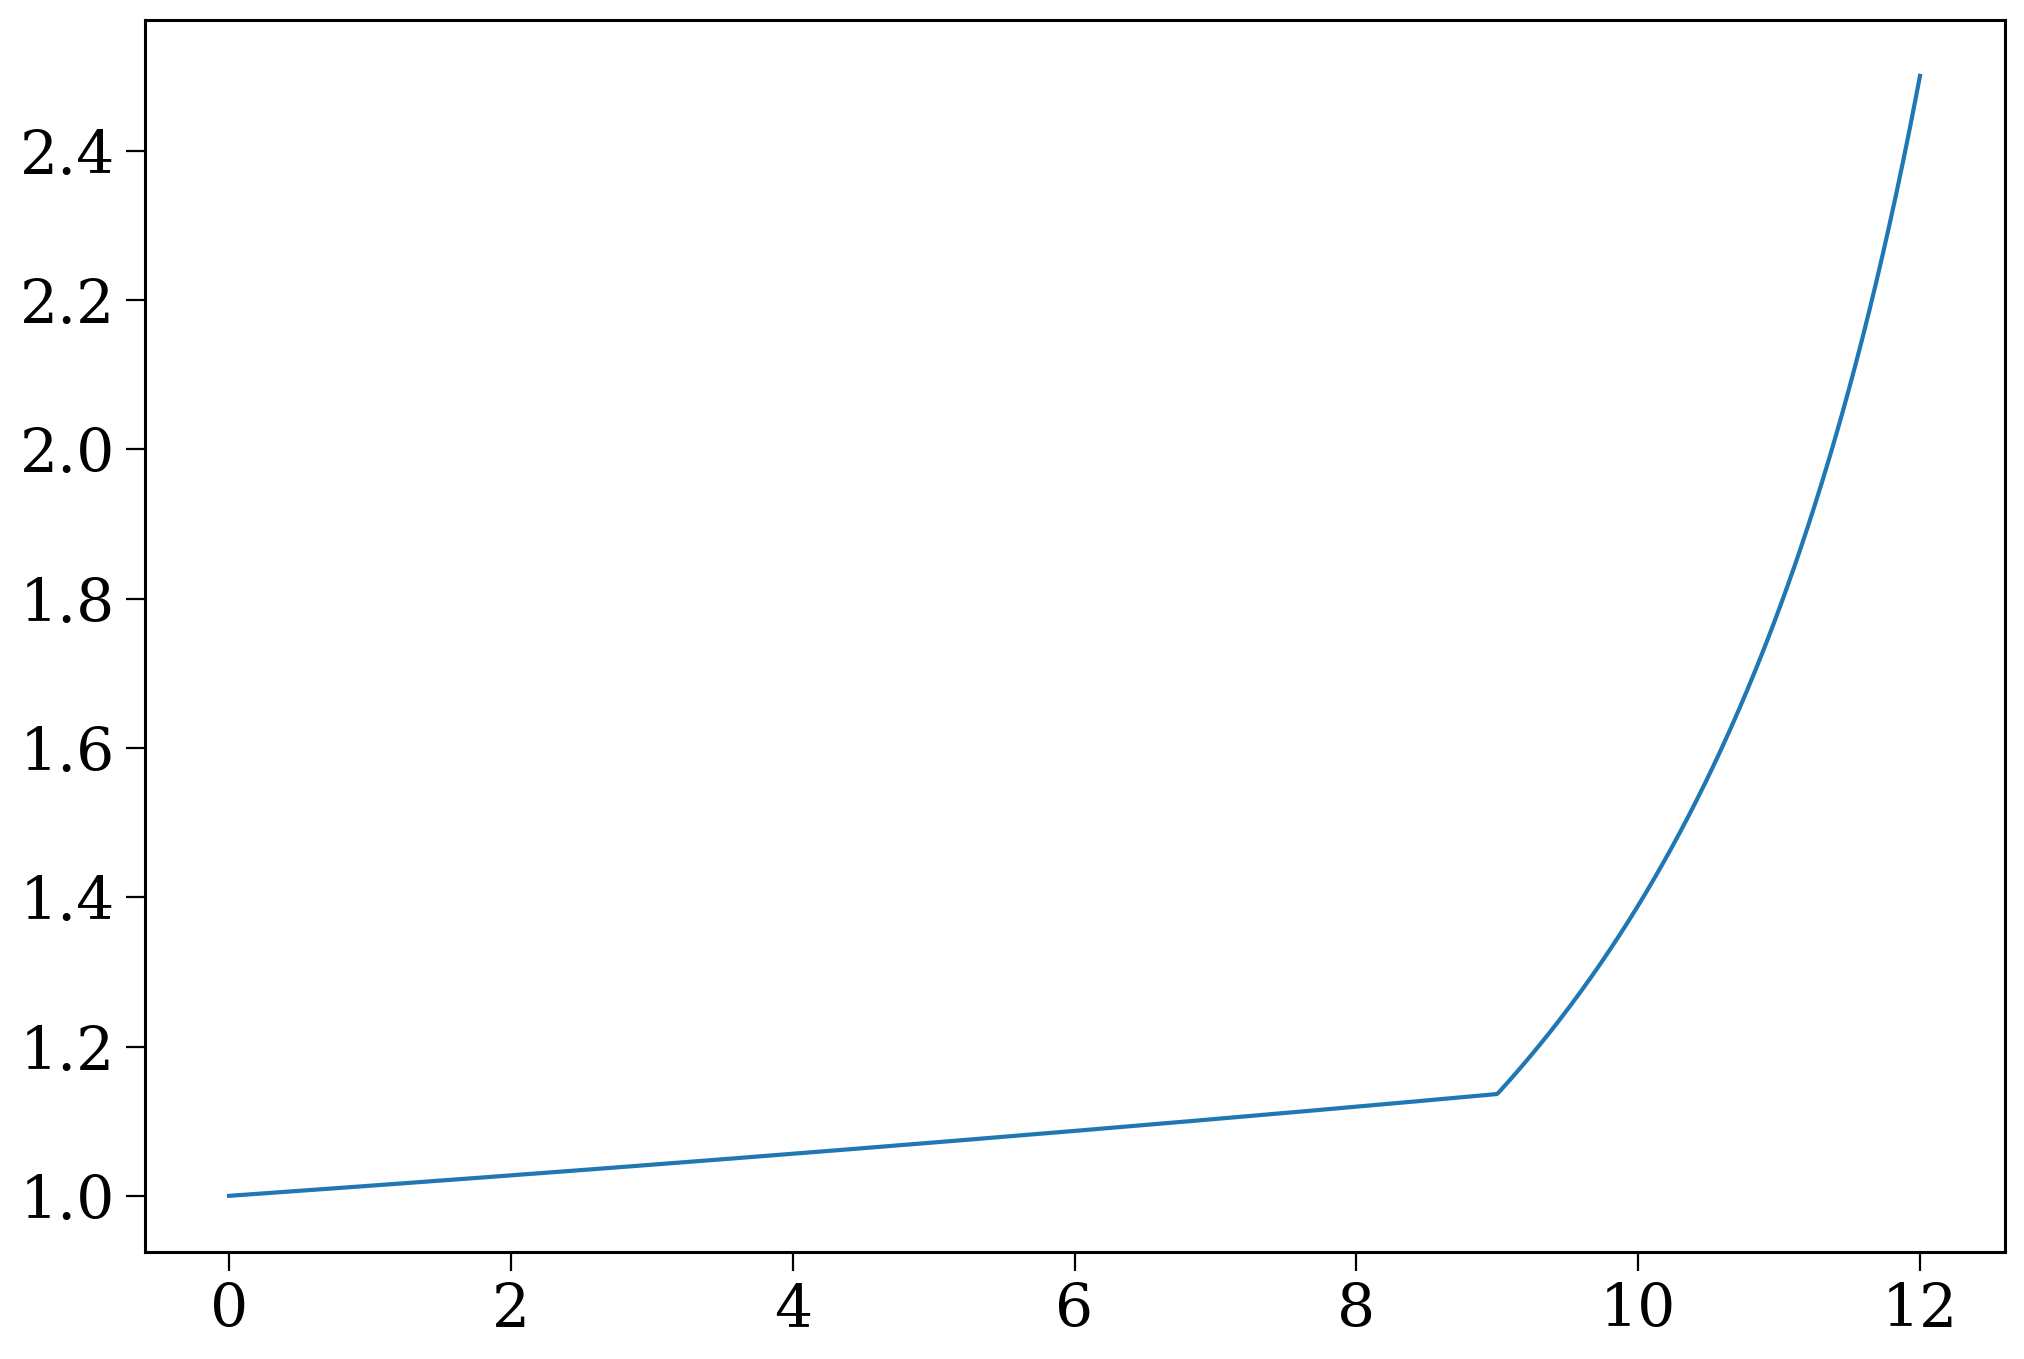

In [16]:
plt.plot(tau_range, f_range)

In [29]:
from scipy.interpolate import interp1d
tau_range = np.linspace(0, 12, 1000)
f_vals = 1 / dm_mass_growth_at_tau(tau_range)

tau_from_f = interp1d(f_vals, tau_range)

In [27]:
def p_of_tau(tau):
    tau_f = 8
    tau_s = 0.43
    tau_m = 12
    return np.exp(tau / tau_f - tau_s / (tau_m - tau))

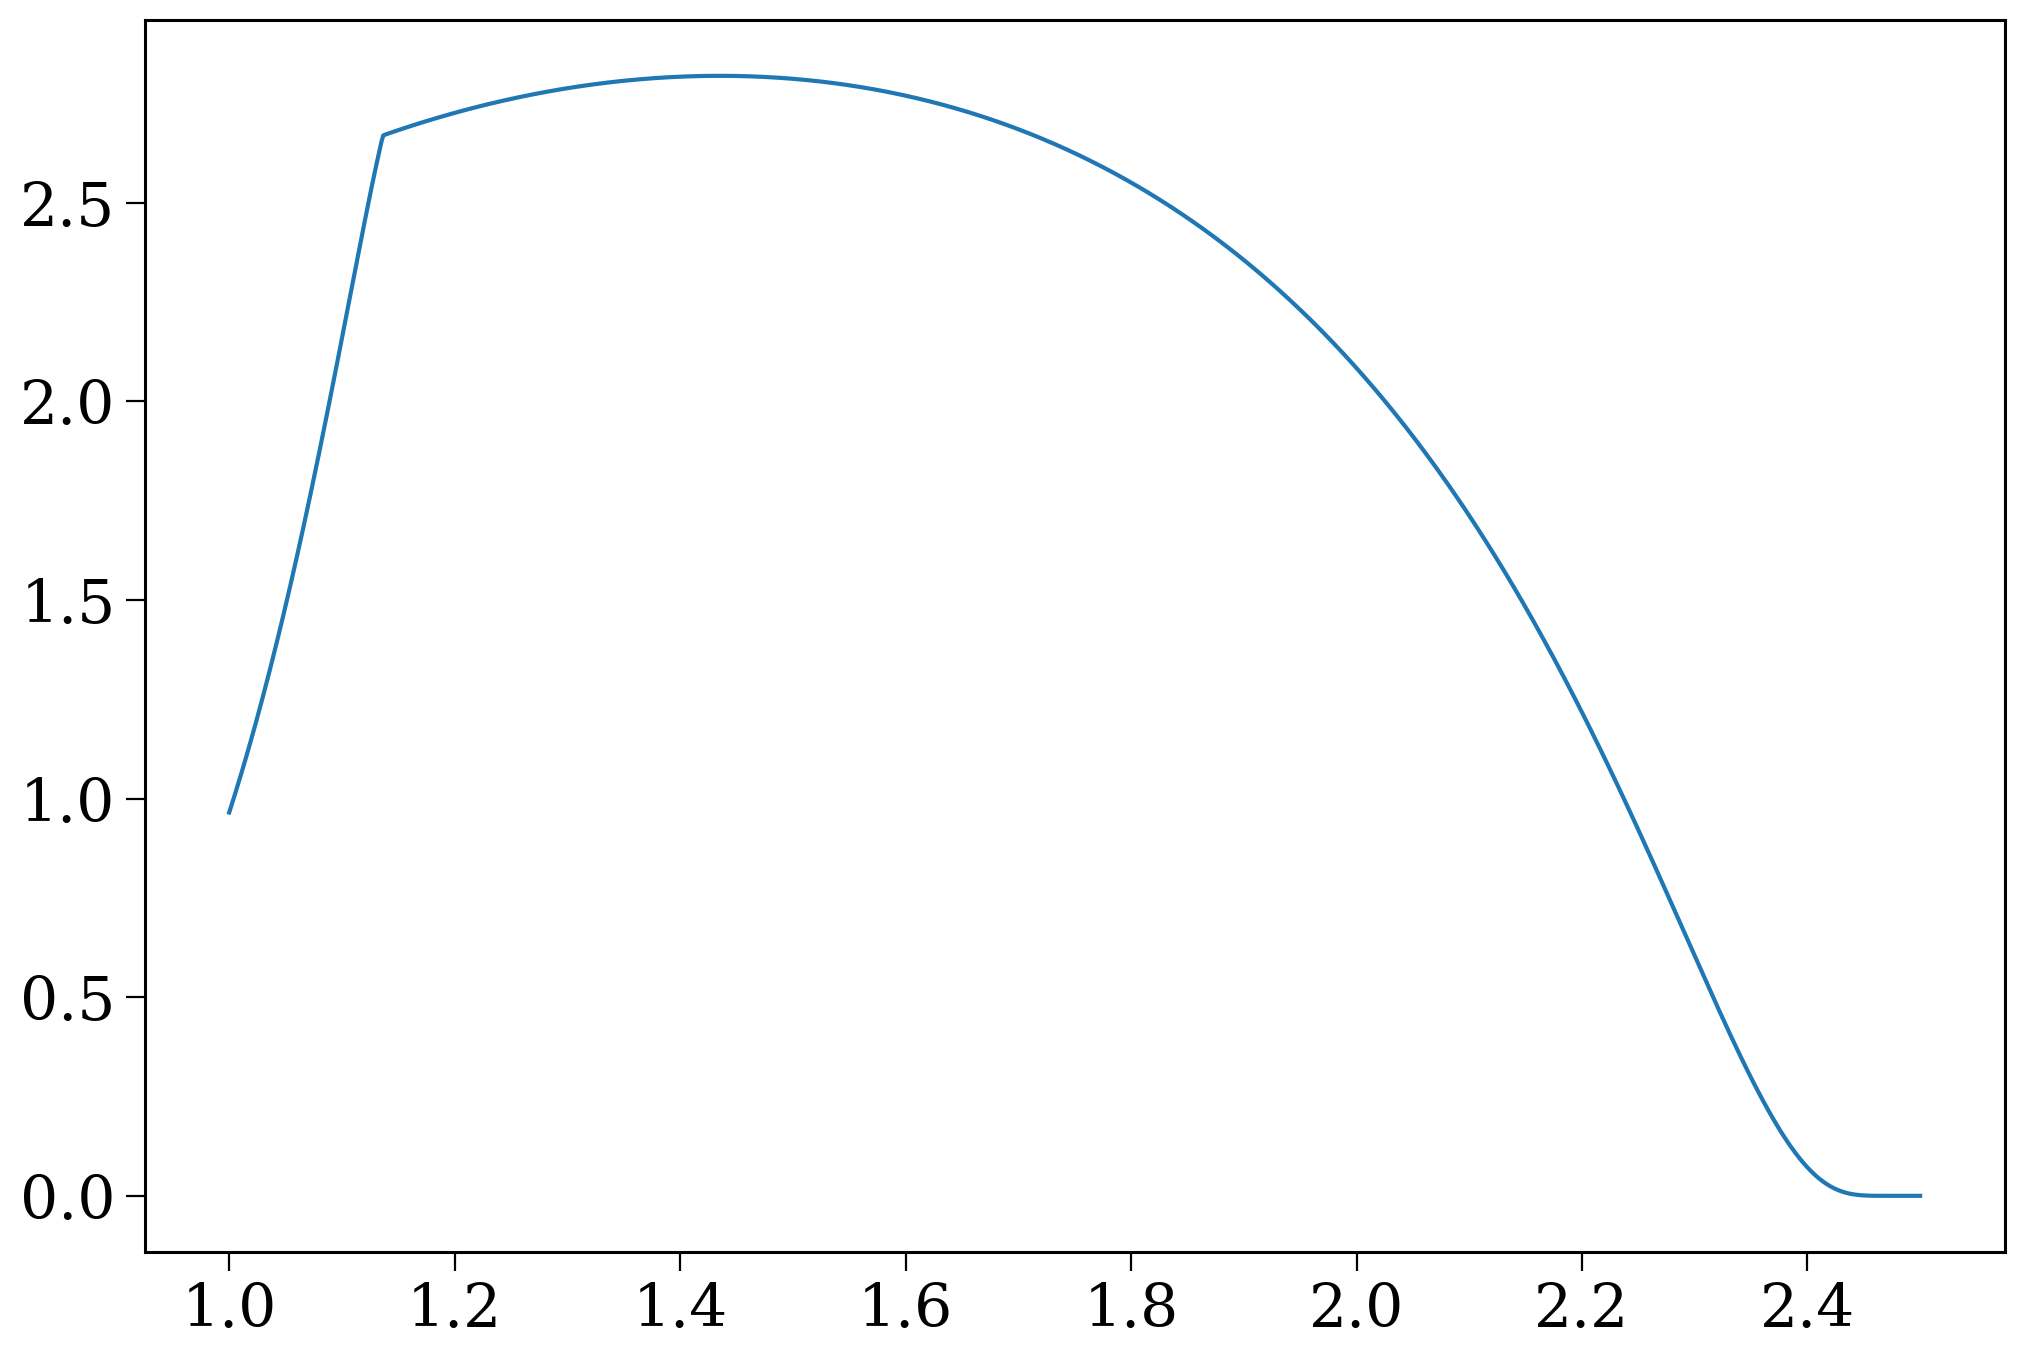

In [32]:
f_range = np.linspace(1, 2.4999, 1000)

p_of_f = p_of_tau(tau_from_f(f_range))

plt.plot(f_range, p_of_f)

In [35]:
np.trapezoid(f_range**(1/4), f_range)

np.float64(1.714741093310659)

In [36]:
np.trapezoid(p_of_f, f_range)

np.float64(2.9941200394371377)

In [40]:
s = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part0.h5")

cogsworth warning: file was saved with gala v1.11.1.dev18 but you are using v1.11.1.dev77


In [62]:
s.kick_info.loc[bh_sec_nums]

,star,disrupted,natal_kick,phi,theta,mean_anomaly,delta_vsysx_1,delta_vsysy_1,delta_vsysz_1,vsys_1_total,delta_vsysx_2,delta_vsysy_2,delta_vsysz_2,vsys_2_total,theta_euler,phi_euler,psi_euler,randomseed,bin_num
12,1.0,0.0,48.653611,-37.683690,168.104489,309.334123,-12.646062,0.827081,-8.543544,15.283949,0.000000,0.000000,0.000000,0.000000,76.336961,127.774108,-91.141106,-1.093540e+09,12.0
12,2.0,1.0,181.922833,11.247623,133.148074,204.811635,-0.106571,0.062574,0.191444,15.270190,-76.188166,108.602330,124.289316,181.788165,164.915968,264.445124,81.629705,2.441485e+08,12.0
76,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,76.0
76,2.0,1.0,67.165171,36.965697,267.839556,0.000000,0.000000,0.000000,0.000000,0.000000,-2.023047,-53.626535,40.388888,67.165171,0.000000,0.000000,0.000000,-1.049097e+09,76.0
100,1.0,1.0,94.429100,-0.645040,354.716992,55.398731,88.774848,-6.096223,-1.057639,88.990203,4.374518,-2.380075,-0.003029,4.980077,179.187005,83.251503,177.125670,-1.319083e+09,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317779,2.0,1.0,2.459899,17.258974,110.624052,0.000000,0.000000,0.000000,0.000000,0.000000,-0.827448,2.198586,0.729830,2.459899,0.000000,0.000000,0.000000,-5.041788e+08,317779.0
317789,1.0,0.0,0.000000,-9.199399,23.787637,7.374905,0.019935,-0.153505,-0.000000,0.154794,0.000000,0.000000,0.000000,0.000000,0.000000,298.232567,-292.197375,-2.507859e+08,317789.0
317789,2.0,0.0,8.726998,-58.465303,67.091258,83.947740,1.093625,1.930055,-3.271492,3.885718,0.000000,0.000000,0.000000,0.000000,27.207033,-94.004513,108.593751,2.003862e+09,317789.0
317824,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,317824.0


In [63]:
bh_prim_nums = s.bin_nums[s.final_bpp["kstar_1"] == 14]
bh_sec_nums = s.bin_nums[s.final_bpp["kstar_2"] == 14]

bh_kicks_prim = s.kick_info.loc[bh_prim_nums][s.kick_info.loc[bh_prim_nums]["star"] == 1]["natal_kick"].values
bh_kicks_sec = s.kick_info.loc[bh_sec_nums][s.kick_info.loc[bh_sec_nums]["star"] == 2]["natal_kick"].values

print(len(bh_prim_nums), len(bh_sec_nums))
print(len(bh_kicks_prim), len(bh_kicks_sec))

bh_times_prim = s.initial_galaxy.tau[s.final_bpp["kstar_1"] == 14]
bh_times_sec = s.initial_galaxy.tau[s.final_bpp["kstar_2"] == 14]

print(len(bh_times_prim), len(bh_times_sec))

bh_times = bh_times_prim.to(u.Gyr).value#np.concatenate([bh_times_prim, bh_times_sec]).to(u.Gyr).value
bh_kicks = bh_kicks_prim#np.concatenate([bh_kicks_prim, bh_kicks_sec])

print(len(bh_times), len(bh_kicks))

41477 15033
41477 14583
41477 15033
41477 41477


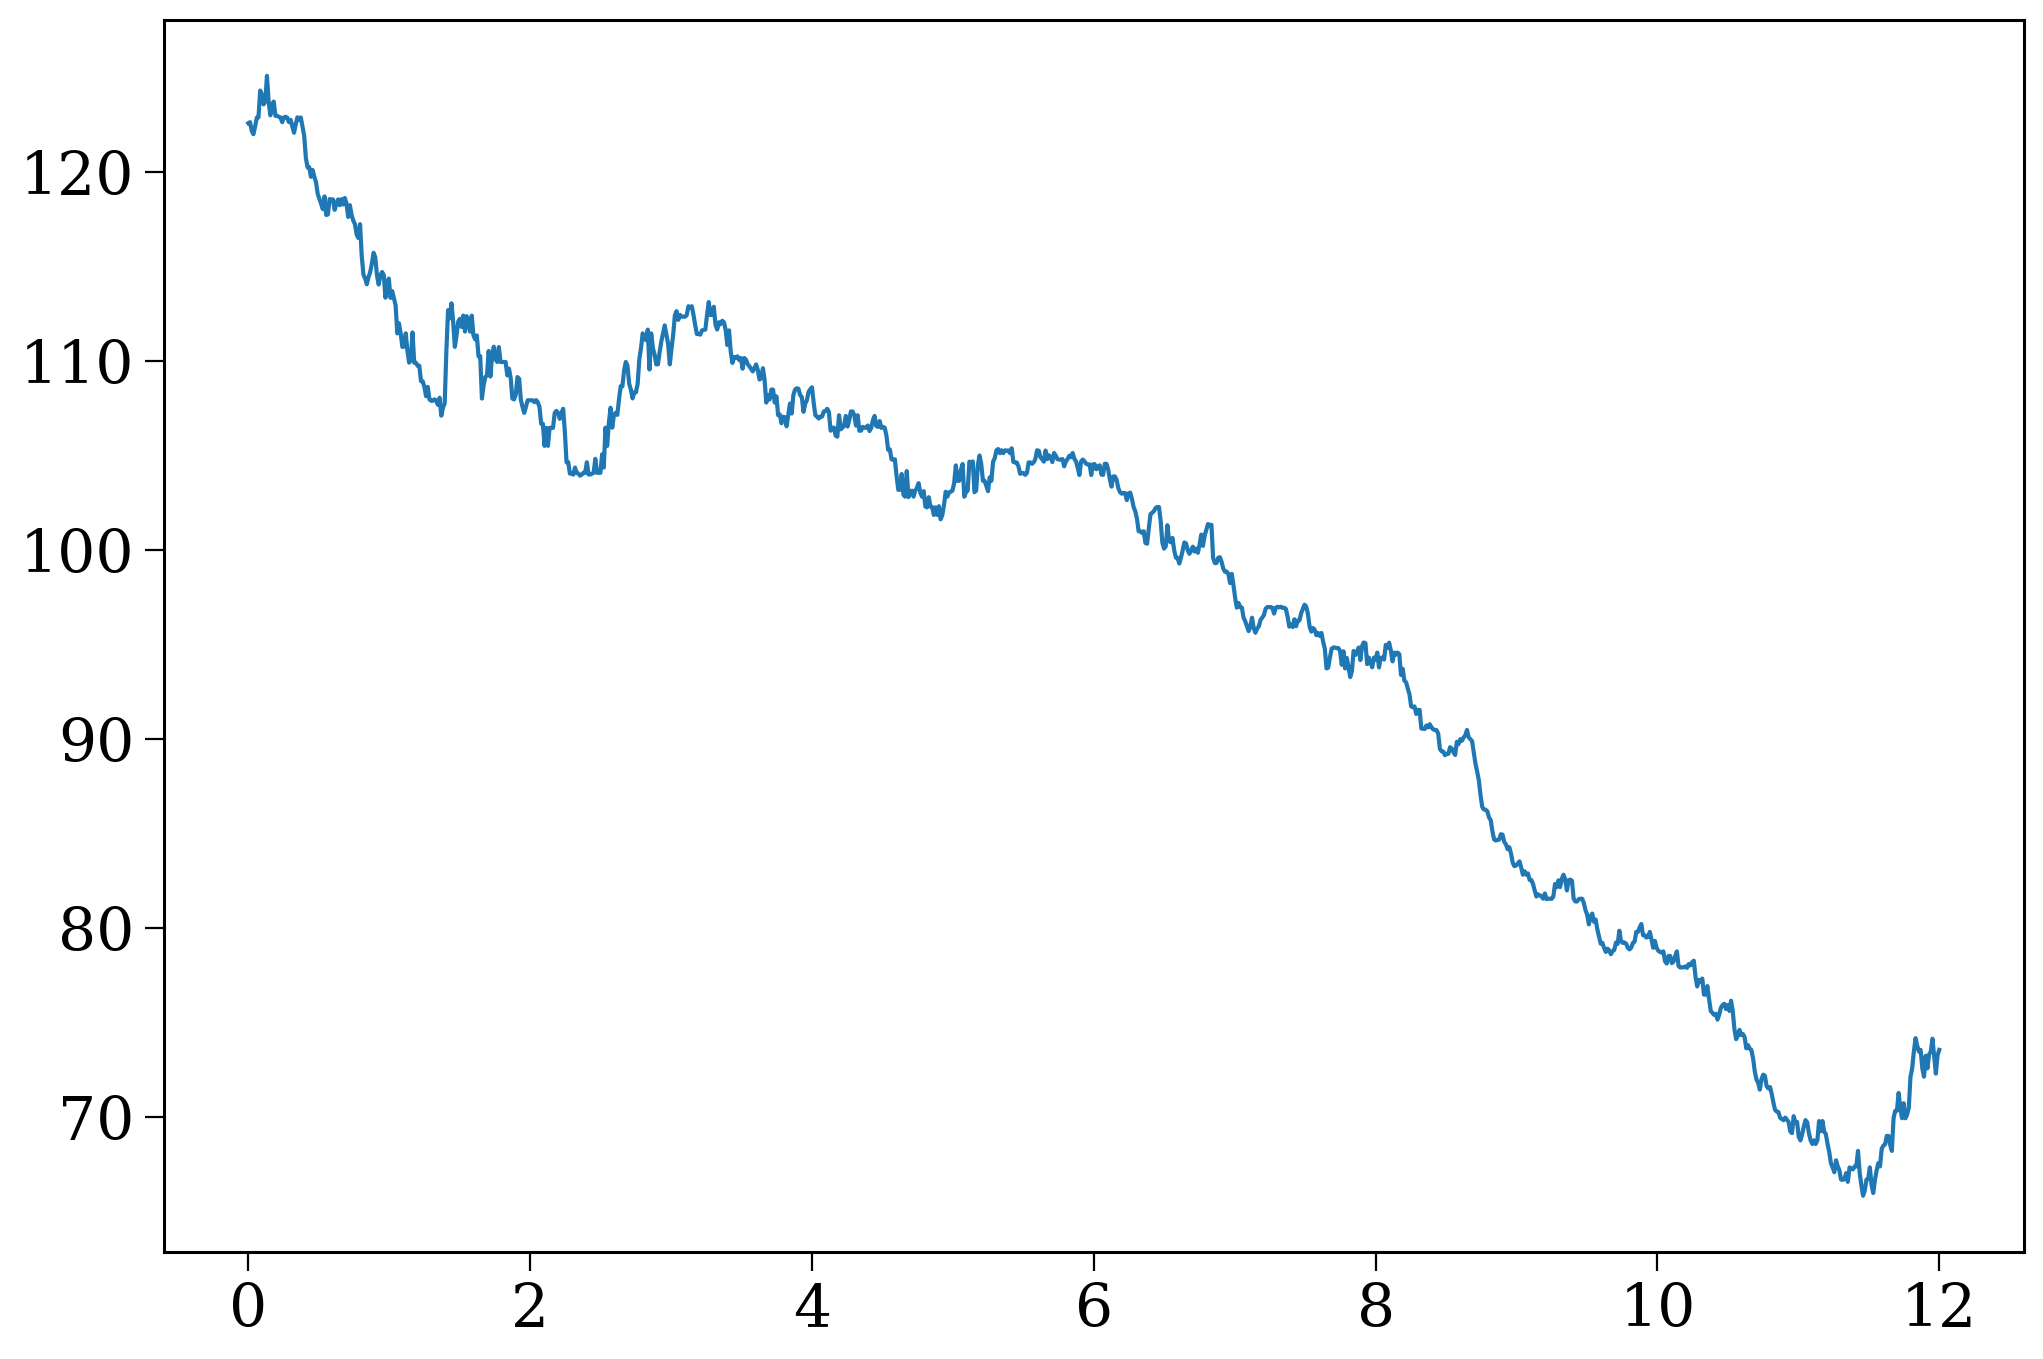

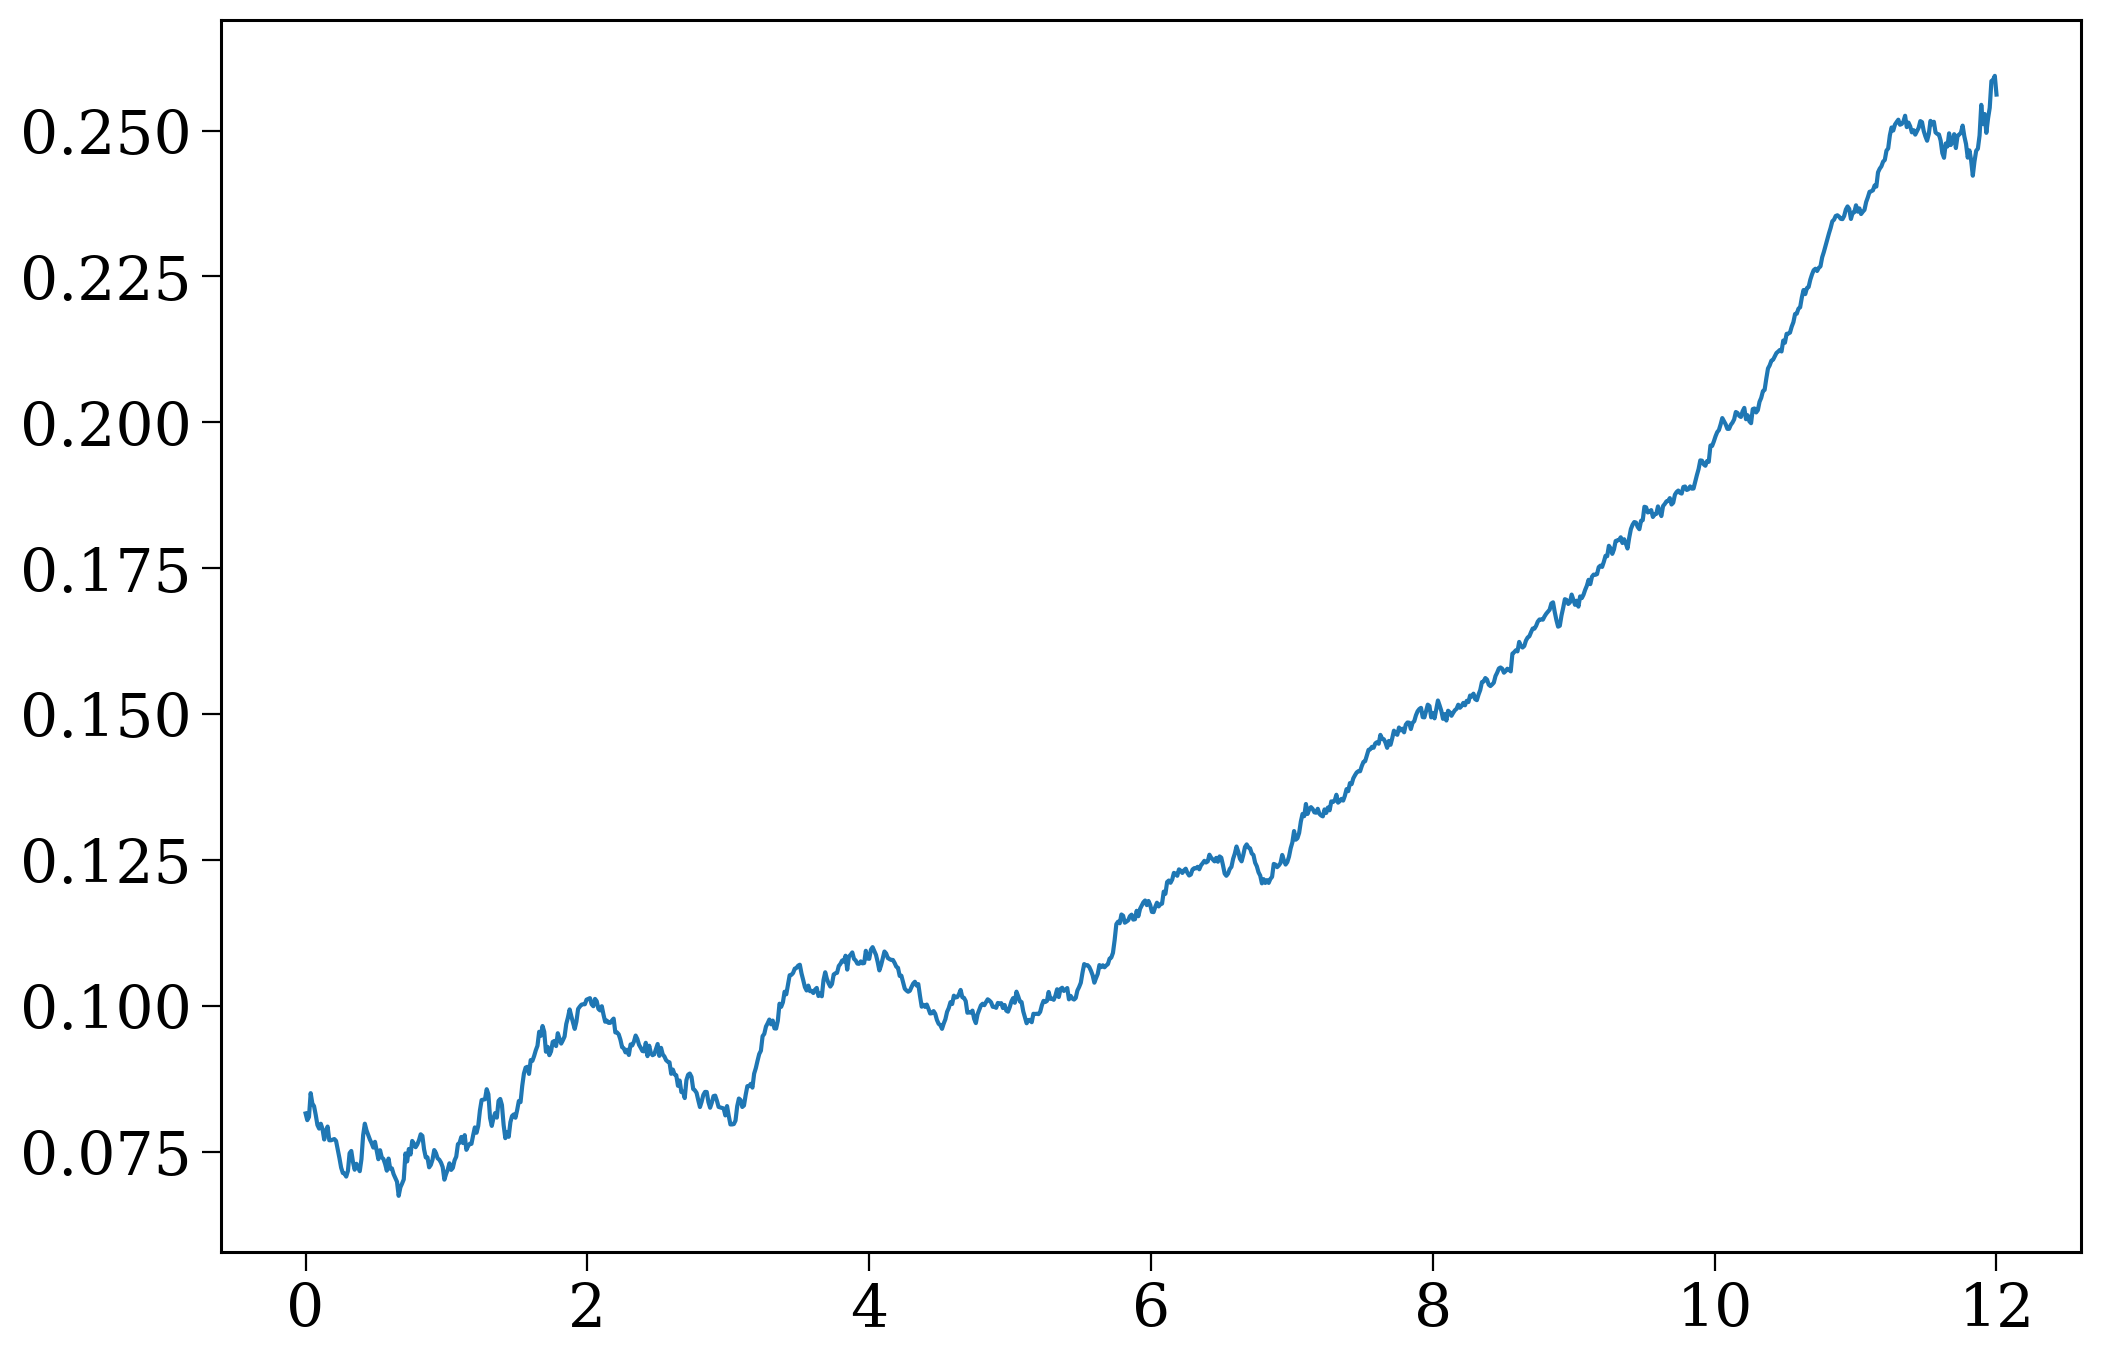

In [70]:
# plot the average kick as a function of time with a moving window
window_width = 1
tau_range = np.linspace(0, 12, 1000)
avg_kicks = []
f_unkicked = []
for tau in tau_range:
    mask = (bh_times > tau - window_width / 2) & (bh_times <= tau + window_width / 2)
    avg_kicks.append(np.median(bh_kicks[mask]))
    f_unkicked.append((bh_kicks[mask] == 0).sum() / mask.sum())

plt.plot(tau_range, avg_kicks)
plt.show()
plt.plot(tau_range, f_unkicked)

In [41]:
s.kick_info

,star,disrupted,natal_kick,phi,theta,mean_anomaly,delta_vsysx_1,delta_vsysy_1,delta_vsysz_1,vsys_1_total,delta_vsysx_2,delta_vsysy_2,delta_vsysz_2,vsys_2_total,theta_euler,phi_euler,psi_euler,randomseed,bin_num
0,1.0,1.0,166.228388,51.999736,117.155424,0.000000,-46.709038,91.060145,130.989286,166.228388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.948990e+09,0.0
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0
2,1.0,1.0,311.113656,29.203434,217.205458,159.422361,-216.513713,-164.952866,151.789468,311.653138,1.898447,5.990459,0.007518,6.284088,34.503224,147.609022,144.845681,-1.084200e+08,2.0
2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.0
3,1.0,1.0,418.300585,10.643220,346.218274,0.000000,399.268706,-97.934787,77.257088,418.300585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.535629e+08,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317825,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,317825.0
317826,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,317826.0
317826,2.0,1.0,60.261837,-58.764241,241.156275,0.000000,0.000000,0.000000,0.000000,0.000000,-15.075418,-27.372582,-51.526328,60.261837,0.000000,0.000000,0.000000,-1.188735e+09,317826.0
317828,1.0,1.0,205.532977,12.237845,218.529053,0.000000,-157.133180,-125.119517,43.566899,205.532977,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.332179e+07,317828.0


In [79]:
np.trapezoid(p_of_f * f_range**(1/4), f_range) / np.trapezoid(p_of_f, f_range)

np.float64(1.1210497030611548)